# Unified Evaluation — Total Processing Value (TPV)
# v1 vs v2 vs v3 vs v4 vs v5 (dollar-conformal) · Context lengths {1, 3, 6}

**Goal:** Predict **total processing value** (monthly dollar volume) instead of avg_proc_cost_pct.
Uses `log1p(total_processing_value)` as the working target to handle heavy right-skew
(raw skewness ≈ 21.5 → −0.03 after log1p).

**v3 improvements** (TPV-specific):
- Decompose TPV into its two channels: `log(txn_count)` and `log(avg_txn_value)` as model features
- Add `last_month` feature and component-level momentum (`momentum_tc`, `momentum_atv`)
- Fix sample weighting: `1 / log1p(txn_count)` upweights low-activity merchants (harder to predict)
- Use GBR regressor instead of HuberRegressor (captures non-linear interactions in TPV)

**v4 improvements** (hardened for dollar accuracy + coverage):
- **Prediction clipping**: `clip(model_pred − baseline, ±clip_radius)` prevents catastrophic dollar errors on high-TPV merchants (top 1% drove +$7.9M excess dollar error in v3)
- **Conformal calibration boost**: calibrate at 93% so joint coverage reliably lands ≥ 90% after temporal shift
- **Adaptive GBR**: scale `n_estimators` inversely with context length to prevent overfitting at ctx=6
- Same v3 features — improvements are in the prediction + conformal pipeline

**v5 improvements** (dollar-space conformal — architectural fix):
- **Regressor**: HuberRegressor in log-space (v3's 11 features) — 100x faster than GBR
- **Bias correction**: `expm1(pred_log + σ²/2)` corrects Jensen's inequality under-prediction
- **Dollar-space conformal**: calibration residuals computed in $ not log-space — eliminates the convexity amplification that made all prior versions have worse dollar MAE than baseline
- **Dollar-space risk stratification**: GBR risk model trained on dollar residuals
- Same architecture as the working avg_proc_cost pipeline (conformal in native reporting space)

Evaluates across `CONTEXT_LEN ∈ {1, 3, 6}` with shared data splits and pool caches.

| Section | Content |
|---|---|
| §1 | Configuration & data loading |
| §2 | Core helper functions |
| §3 | Feature function definitions (v1 – v5) |
| §4 | Pipeline utilities (conformal, stratification) |
| §5 | Evaluation engine |
| §6 | Pre-compute scenarios & caches |
| §7 | Execute evaluation loop |
| §8 | Comparison dashboard |
| §9 | Summary |

## §1 · Configuration & Data Loading

In [1]:
import os, math, warnings, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

# ── Pipeline configuration ────────────────────────────────────────────────────
TARGET_COL   = 'total_processing_value'
LOG_TARGET   = 'log_tpv'                 # log1p(total_processing_value)
CONTEXT_LENS = [1, 3, 6]
HORIZON_LEN  = 3
TARGET_COV   = 0.90
MIN_POOL     = 10
KNN_K        = 10

# ── Stratification guard (production values) ──────────────────────────────────
VOL_MIN_GAIN_ABS   = 0.05
VOL_MIN_GAIN_REL   = 0.01
VOL_TEST_COV_SLACK = 0.03
_VOL_EPS           = 1e-6

In [2]:
V2_CSV = 'df_5411_merchants_mthly_v2.csv'
V1_CSV = 'df_5411_merchants_mthly_25th_Mar.csv'

if os.path.exists(V2_CSV):
    df = pd.read_csv(V2_CSV)
    print(f'Loaded v2 CSV: {df.shape[0]:,} rows × {df.shape[1]} cols')
elif os.path.exists(V1_CSV):
    df = pd.read_csv(V1_CSV)
    print(f'⚠ v2 CSV not found — loaded v1 CSV: {df.shape[0]:,} rows × {df.shape[1]} cols')
else:
    raise FileNotFoundError('No monthly CSV found. Run Generate_mthly_v2.ipynb first.')

# Create log-transformed target
assert TARGET_COL in df.columns, f'{TARGET_COL} not found in CSV'
df[LOG_TARGET] = np.log1p(df[TARGET_COL])
print(f'✓ Created {LOG_TARGET} column (log1p of {TARGET_COL})')
print(f'  {TARGET_COL}: mean={df[TARGET_COL].mean():.2f}, median={df[TARGET_COL].median():.2f}, '
      f'skew={df[TARGET_COL].skew():.2f}')
print(f'  {LOG_TARGET}: mean={df[LOG_TARGET].mean():.2f}, median={df[LOG_TARGET].median():.2f}, '
      f'skew={df[LOG_TARGET].skew():.2f}')

# Check v2 columns
V2_COLS = ['std_proc_cost_pct', 'iqr_proc_cost_pct', 'std_txn_amount',
           'median_txn_amount', 'n_unique_cost_types', 'median_proc_cost_pct']
missing = [c for c in V2_COLS if c not in df.columns]
RUN_V2 = len(missing) == 0
if not RUN_V2:
    print(f'⚠ Missing v2 columns: {missing}')
    print(f'  v2 features will be SKIPPED. Run Generate_mthly_v2.ipynb to enable.')
else:
    print(f'✓ All v2 columns present')

print(f'Merchants: {df["merchant_id"].nunique():,}')
COST_TYPE_COLS = [f'cost_type_{i}_pct' for i in range(1, 62)]

Loaded v2 CSV: 131,488 rows × 77 cols
✓ Created log_tpv column (log1p of total_processing_value)
  total_processing_value: mean=273.79, median=78.30, skew=21.51
  log_tpv: mean=4.22, median=4.37, skew=-0.03
✓ All v2 columns present
Merchants: 7,996


## §2 · Core Helper Functions

- **`get_test_scenario`** — slides a (context, horizon) window over a merchant's history
- **`generate_pool`** — returns all peer rows ≤ a given date, excluding the target merchant
- **`find_valid_merchants`** — filters to merchants with enough months for at least one scenario

In [3]:
def get_test_scenario(df, onboard_merchant_id, context_len, context_max_NAN_months,
                      horizon_len, horizon_max_NAN_months):
    merchant_data = df[df['merchant_id'] == onboard_merchant_id].copy()
    if len(merchant_data) == 0:
        return []
    merchant_data = merchant_data.sort_values(['year', 'month']).reset_index(drop=True)
    valid_scenarios = []
    for start_idx in range(len(merchant_data) - context_len - horizon_len + 1):
        context_end_idx = start_idx + context_len - 1
        context_window  = merchant_data.iloc[start_idx:context_end_idx + 1].copy().reset_index(drop=True)
        if len(context_window) > 0:
            context_start = (int(context_window.iloc[0]['year']),  int(context_window.iloc[0]['month']))
            context_end   = (int(context_window.iloc[-1]['year']), int(context_window.iloc[-1]['month']))
            expected_ctx  = (context_end[0] - context_start[0]) * 12 + (context_end[1] - context_start[1]) + 1
            nan_ctx       = expected_ctx - len(context_window)
        else:
            nan_ctx = context_len
        if nan_ctx > context_max_NAN_months or len(context_window) == 0:
            continue
        horizon_start_idx = context_end_idx + 1
        horizon_end_idx   = horizon_start_idx + horizon_len - 1
        if horizon_end_idx >= len(merchant_data):
            continue
        horizon_window = merchant_data.iloc[horizon_start_idx:horizon_end_idx + 1].copy().reset_index(drop=True)
        if len(horizon_window) > 0:
            horizon_start = (int(horizon_window.iloc[0]['year']),  int(horizon_window.iloc[0]['month']))
            horizon_end   = (int(horizon_window.iloc[-1]['year']), int(horizon_window.iloc[-1]['month']))
            expected_hor  = (horizon_end[0] - horizon_start[0]) * 12 + (horizon_end[1] - horizon_start[1]) + 1
            nan_hor       = expected_hor - len(horizon_window)
            ctx_hor_gap   = (horizon_start[0] - context_end[0]) * 12 + (horizon_start[1] - context_end[1]) - 1
        else:
            nan_hor     = horizon_len
            ctx_hor_gap = 999
        if nan_hor <= horizon_max_NAN_months and len(horizon_window) > 0 and ctx_hor_gap == 0:
            valid_scenarios.append({
                'context_data' : context_window,
                'horizon_data' : horizon_window,
                'context_range': (context_start, context_end),
                'horizon_range': (horizon_start, horizon_end),
                'context_gaps' : nan_ctx,
                'horizon_gaps' : nan_hor,
            })
    return valid_scenarios


def generate_pool(df, onboard_merchant_id, year, month):
    return df[
        (df['merchant_id'] != onboard_merchant_id) &
        ((df['year'] < year) | ((df['year'] == year) & (df['month'] <= month)))
    ].copy()


def find_valid_merchants(df, context_len, horizon_len, n_merchants=10, seed=42):
    rng_vm     = np.random.default_rng(seed)
    min_months = context_len + horizon_len
    all_ids    = rng_vm.permutation(df['merchant_id'].unique())
    valid = []
    for mid in all_ids:
        months = df[df['merchant_id'] == mid].groupby(['year', 'month']).size()
        if len(months) >= min_months:
            valid.append(mid)
            if len(valid) >= n_merchants:
                break
    return valid

## §3 · Feature Functions (v1 / v2 / v3 / v4 / v5) — TPV Target

### Model features
| Version | Features | Regressor | Notes |
|---|---|---|---|
| v1 | context_mean, context_std, momentum, pool_mean | Huber | All computed from log_tpv |
| v2 | v1 + txn_amount_std, log_txn_count, avg_median_txn_gap | Huber | Transaction-level signals |
| v3 | v2 + last_month, log_avg_txn_val, momentum_tc, momentum_atv | GBR(200) | TPV decomposition + recency |
| v4 | Same as v3 (11 features) | GBR(300/ctx) | Clipping + cal boost |
| v5 | Same as v3 (11 features) | **Huber** | Dollar-space conformal, bias-corrected back-transform |

### Risk features
| Version | Features | Residual space |
|---|---|---|
| v1 | 4 context-window + 2 peer-relative | log |
| v2 | 6 transaction-level + 2 peer-relative + 1 graceful-degrade | log |
| v3/v4 | v2 + tc_cov + atv_cov (component volatility) | log |
| v5 | Same as v3 (11 risk features) | **dollar** |

### v5 key changes (architectural)
- **Predict in log, calibrate in dollars**: HuberRegressor fits log_tpv, then `expm1(pred + σ²/2)` bias-corrects for Jensen's inequality
- **Dollar-space conformal**: `|actual_$ − pred_$|` residuals → dollar half-widths → symmetric $ CIs
- **No StandardScaler** for v5 (tree-derived features + log-scaled inputs already well-conditioned)
- ~100x faster than v3/v4 (Huber vs GBR)

In [51]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODEL FEATURES  (target = log_tpv)
# ═══════════════════════════════════════════════════════════════════════════════

FEAT_NAMES_V1 = ['context_mean', 'context_std', 'momentum', 'pool_mean']

def build_features_v1(scenarios, cache):
    """Original 4 features, now computed from log_tpv."""
    rows = []
    for s in scenarios:
        vals   = s['context_data'][LOG_TARGET].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(s['context_data'].iloc[-1]['year']),
                  int(s['context_data'].iloc[-1]['month']))
        p_mean = cache[key]
        rows.append([c_mean, c_std, mom, p_mean])
    return np.array(rows, dtype=float)


FEAT_NAMES_V2 = ['context_mean', 'context_std', 'momentum', 'pool_mean',
                  'txn_amount_std', 'log_txn_count', 'avg_median_txn_gap']

def build_features_v2(scenarios, cache):
    """Augmented 7 features: v1 + 3 transaction-level (TPV-relevant)."""
    rows = []
    for s in scenarios:
        ctx  = s['context_data']
        vals = ctx[LOG_TARGET].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(ctx.iloc[-1]['year']),
                  int(ctx.iloc[-1]['month']))
        p_mean = cache[key]

        # NEW: transaction-level features relevant to TPV
        txn_amount_std  = float(ctx['std_txn_amount'].fillna(0).mean())
        log_txn         = float(np.log1p(ctx['transaction_count'].mean()))
        avg_median_gap  = float(np.mean(np.abs(
            ctx['avg_transaction_value'].values - ctx['median_txn_amount'].values
        )))

        rows.append([c_mean, c_std, mom, p_mean, txn_amount_std, log_txn, avg_median_gap])
    return np.array(rows, dtype=float)


# ── v3: TPV-optimised features ────────────────────────────────────────────────
FEAT_NAMES_V3 = ['context_mean', 'context_std', 'momentum', 'pool_mean',
                  'txn_amount_std', 'log_txn_count', 'avg_median_txn_gap',
                  'last_month', 'log_avg_txn_val', 'momentum_tc', 'momentum_atv']

def build_features_v3(scenarios, cache):
    """11 features: v2 + TPV decomposition (last_month, log_avg_txn_val, component momentum)."""
    rows = []
    for s in scenarios:
        ctx  = s['context_data']
        vals = ctx[LOG_TARGET].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(ctx.iloc[-1]['year']),
                  int(ctx.iloc[-1]['month']))
        p_mean = cache[key]

        # v2 features
        txn_amount_std  = float(ctx['std_txn_amount'].fillna(0).mean())
        log_txn         = float(np.log1p(ctx['transaction_count'].mean()))
        avg_median_gap  = float(np.mean(np.abs(
            ctx['avg_transaction_value'].values - ctx['median_txn_amount'].values
        )))

        # v3: recency — last month's log_tpv
        last_month = float(vals[-1])

        # v3: TPV decomposition — separate channels
        log_avg_txn_val = float(np.log1p(ctx['avg_transaction_value'].mean()))

        # v3: component-level momentum
        tc_vals  = np.log1p(ctx['transaction_count'].values.astype(float))
        atv_vals = np.log1p(ctx['avg_transaction_value'].values.astype(float))
        mom_tc  = float(tc_vals[-1]  - np.mean(tc_vals))
        mom_atv = float(atv_vals[-1] - np.mean(atv_vals))

        rows.append([c_mean, c_std, mom, p_mean,
                     txn_amount_std, log_txn, avg_median_gap,
                     last_month, log_avg_txn_val, mom_tc, mom_atv])
    return np.array(rows, dtype=float)


# ═══════════════════════════════════════════════════════════════════════════════
# RISK FEATURES  (target = log_tpv)
# ═══════════════════════════════════════════════════════════════════════════════

RISK_NAMES_V1 = [
    'ctx_cov', 'ctx_range_ratio', 'ctx_slope_ratio',
    'ctx_last_jump_ratio', 'pool_mean_gap_ratio', 'ctx_to_knn_gap_ratio',
]

def risk_features_v1(s, pool_cache, knn_cache):
    """Original 6 risk features computed from log_tpv."""
    vals   = s['context_data'][LOG_TARGET].values.astype(float)
    c_mean = float(np.mean(vals))
    _denom = c_mean + _VOL_EPS

    ctx_cov         = float(np.std(vals)) / _denom
    ctx_range_ratio = (float(np.max(vals)) - float(np.min(vals))) / _denom
    x_idx           = np.arange(len(vals), dtype=float)
    ctx_slope_ratio = float(np.polyfit(x_idx, vals, 1)[0]) / _denom if len(vals) >= 2 else 0.0
    ctx_last_jump   = (float(vals[-1]) - float(vals[-2])) / _denom if len(vals) >= 2 else 0.0

    yr, mo  = s['context_range'][1]
    mid     = int(s['merchant_id'])
    flat_pm = float(pool_cache.get((mid, yr, mo), c_mean))
    knn_pm  = float(knn_cache.get((mid, yr, mo), c_mean))
    pool_gap = abs(c_mean - flat_pm) / (flat_pm + _VOL_EPS)
    knn_gap  = abs(c_mean - knn_pm)  / (knn_pm  + _VOL_EPS)

    return np.array([ctx_cov, ctx_range_ratio, ctx_slope_ratio, ctx_last_jump,
                     pool_gap, knn_gap], dtype=float)


RISK_NAMES_V2 = [
    'intra_txn_cov', 'avg_median_txn_gap', 'log_txn_count',
    'cost_type_hhi', 'log_avg_txn_val', 'txn_amount_cov',
    'pool_mean_gap_ratio', 'ctx_to_knn_gap_ratio', 'ctx_cov',
]

def risk_features_v2(s, pool_cache, knn_cache):
    """v2 risk features: 6 txn-level + 2 peer-relative + 1 graceful-degrade."""
    ctx    = s['context_data']
    vals   = ctx[LOG_TARGET].values.astype(float)
    c_mean = float(np.mean(vals))
    _denom = c_mean + _VOL_EPS

    # ── Category A: Intra-month transaction-level (stable at ctx=1) ───────────
    avg_txn_val     = float(ctx['avg_transaction_value'].mean())
    intra_txn_cov   = float(ctx['std_txn_amount'].fillna(0).mean()) / (avg_txn_val + _VOL_EPS)
    avg_median_gap  = float(np.mean(np.abs(
        ctx['avg_transaction_value'].values - ctx['median_txn_amount'].values
    ))) / (avg_txn_val + _VOL_EPS)
    log_txn_count   = float(np.log1p(ctx['transaction_count'].mean()))

    # Cost type HHI — concentration of payment mix
    ct_cols = [c for c in ctx.columns if c.startswith('cost_type_') and c.endswith('_pct')]
    ct_vals = ctx[ct_cols].mean().values if ct_cols else np.array([1.0])
    cost_type_hhi = float(np.sum(ct_vals ** 2))

    log_avg_txn_val = float(np.log1p(avg_txn_val))
    txn_amount_cov  = float(ctx['std_txn_amount'].fillna(0).mean()) / (avg_txn_val + _VOL_EPS)

    # ── Category B: Peer-relative (using log_tpv pool means) ──────────────────
    yr, mo  = s['context_range'][1]
    mid     = int(s['merchant_id'])
    flat_pm = float(pool_cache.get((mid, yr, mo), c_mean))
    knn_pm  = float(knn_cache.get((mid, yr, mo), c_mean))
    pool_gap = abs(c_mean - flat_pm) / (flat_pm + _VOL_EPS)
    knn_gap  = abs(c_mean - knn_pm)  / (knn_pm  + _VOL_EPS)

    # ── Category C: Graceful degrade ──────────────────────────────────────────
    ctx_cov = float(np.std(vals)) / _denom

    return np.array([intra_txn_cov, avg_median_gap, log_txn_count,
                     cost_type_hhi, log_avg_txn_val, txn_amount_cov,
                     pool_gap, knn_gap, ctx_cov], dtype=float)


# ── v3 risk features: v2 + component volatility ──────────────────────────────
RISK_NAMES_V3 = [
    'intra_txn_cov', 'avg_median_txn_gap', 'log_txn_count',
    'cost_type_hhi', 'log_avg_txn_val', 'txn_amount_cov',
    'pool_mean_gap_ratio', 'ctx_to_knn_gap_ratio', 'ctx_cov',
    'tc_cov', 'atv_cov',
]

def risk_features_v3(s, pool_cache, knn_cache):
    """v3 risk: v2 + component-level volatility (tc_cov, atv_cov)."""
    ctx    = s['context_data']
    vals   = ctx[LOG_TARGET].values.astype(float)
    c_mean = float(np.mean(vals))
    _denom = c_mean + _VOL_EPS

    # ── Category A: Intra-month transaction-level ─────────────────────────────
    avg_txn_val     = float(ctx['avg_transaction_value'].mean())
    intra_txn_cov   = float(ctx['std_txn_amount'].fillna(0).mean()) / (avg_txn_val + _VOL_EPS)
    avg_median_gap  = float(np.mean(np.abs(
        ctx['avg_transaction_value'].values - ctx['median_txn_amount'].values
    ))) / (avg_txn_val + _VOL_EPS)
    log_txn_count   = float(np.log1p(ctx['transaction_count'].mean()))

    ct_cols = [c for c in ctx.columns if c.startswith('cost_type_') and c.endswith('_pct')]
    ct_vals = ctx[ct_cols].mean().values if ct_cols else np.array([1.0])
    cost_type_hhi = float(np.sum(ct_vals ** 2))

    log_avg_txn_val = float(np.log1p(avg_txn_val))
    txn_amount_cov  = float(ctx['std_txn_amount'].fillna(0).mean()) / (avg_txn_val + _VOL_EPS)

    # ── Category B: Peer-relative ─────────────────────────────────────────────
    yr, mo  = s['context_range'][1]
    mid     = int(s['merchant_id'])
    flat_pm = float(pool_cache.get((mid, yr, mo), c_mean))
    knn_pm  = float(knn_cache.get((mid, yr, mo), c_mean))
    pool_gap = abs(c_mean - flat_pm) / (flat_pm + _VOL_EPS)
    knn_gap  = abs(c_mean - knn_pm)  / (knn_pm  + _VOL_EPS)

    # ── Category C: Graceful degrade ──────────────────────────────────────────
    ctx_cov = float(np.std(vals)) / _denom

    # ── Category D: Component volatility (NEW in v3) ──────────────────────────
    tc_vals  = np.log1p(ctx['transaction_count'].values.astype(float))
    atv_vals = np.log1p(ctx['avg_transaction_value'].values.astype(float))
    tc_mean  = float(np.mean(tc_vals))
    atv_mean = float(np.mean(atv_vals))
    tc_cov   = float(np.std(tc_vals))  / (tc_mean  + _VOL_EPS)
    atv_cov  = float(np.std(atv_vals)) / (atv_mean + _VOL_EPS)

    return np.array([intra_txn_cov, avg_median_gap, log_txn_count,
                     cost_type_hhi, log_avg_txn_val, txn_amount_cov,
                     pool_gap, knn_gap, ctx_cov,
                     tc_cov, atv_cov], dtype=float)


# ── v4: Same features as v3 (changes are in pipeline, not features) ──────────
FEAT_NAMES_V4 = FEAT_NAMES_V3
build_features_v4 = build_features_v3
RISK_NAMES_V4 = RISK_NAMES_V3
risk_features_v4 = risk_features_v3

# ── v5: Same features as v3 (changes are in conformal space, not features) ───
FEAT_NAMES_V5 = FEAT_NAMES_V3
build_features_v5 = build_features_v3
RISK_NAMES_V5 = RISK_NAMES_V3
risk_features_v5 = risk_features_v3

# ── v6: Same features as v3 (changes are in sample weighting + no bias corr) ─
FEAT_NAMES_V6 = FEAT_NAMES_V3
build_features_v6 = build_features_v3
RISK_NAMES_V6 = RISK_NAMES_V3
risk_features_v6 = risk_features_v3


# ═══════════════════════════════════════════════════════════════════════════════
# v7: EXTENDED FEATURES — exogenous signals derivable from existing data
# ═══════════════════════════════════════════════════════════════════════════════
# New features on top of v3's 11:
#   sin_month, cos_month     — cyclical seasonality of prediction month
#   merchant_age             — log1p(months since first appearance)
#   mcc_trend                — MCC-wide mean log_tpv for last context (year, month)
#   days_in_horizon          — avg calendar days across the 3 horizon months
#   cost_hhi_delta           — change in cost_type HHI (first→last context month)
# ═══════════════════════════════════════════════════════════════════════════════

import calendar as _cal

def _precompute_v7_lookups(df_full):
    """One-time precompute of MCC-wide trend and merchant birth dates."""
    # MCC-wide mean log_tpv per (year, month)
    mcc_trend = df_full.groupby(['year', 'month'])[LOG_TARGET].mean().to_dict()

    # Merchant birth: first (year, month) per merchant_id
    first_appear = (df_full.sort_values(['year', 'month'])
                    .groupby('merchant_id')[['year', 'month']].first())
    merchant_birth = {
        mid: (int(row['year']), int(row['month']))
        for mid, row in first_appear.iterrows()
    }
    return mcc_trend, merchant_birth

# will be populated once df is loaded (in precompute cell or first call)
_V7_MCC_TREND = None
_V7_MERCHANT_BIRTH = None

def _ensure_v7_lookups(df_full):
    global _V7_MCC_TREND, _V7_MERCHANT_BIRTH
    if _V7_MCC_TREND is None:
        _V7_MCC_TREND, _V7_MERCHANT_BIRTH = _precompute_v7_lookups(df_full)

def _cost_hhi(row, cost_cols):
    """HHI of cost_type distribution for a single row."""
    pcts = np.array([row.get(c, 0) for c in cost_cols], dtype=float)
    pcts = pcts[pcts > 0]
    if len(pcts) == 0:
        return 0.0
    pcts = pcts / (pcts.sum() + 1e-12)
    return float(np.sum(pcts ** 2))

def _days_in_month(yr, mo):
    return _cal.monthrange(int(yr), int(mo))[1]


FEAT_NAMES_V7 = FEAT_NAMES_V3 + [
    'sin_month', 'cos_month', 'merchant_age',
    'mcc_trend', 'days_in_horizon', 'cost_hhi_delta']

def build_features_v7(scenarios, cache):
    """17 features: v3 (11) + 6 exogenous signals.

    Requires _ensure_v7_lookups(df) to have been called beforehand.
    """

    rows = []
    for s in scenarios:
        ctx  = s['context_data']
        vals = ctx[LOG_TARGET].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(ctx.iloc[-1]['year']),
                  int(ctx.iloc[-1]['month']))
        p_mean = cache[key]

        # v2 features
        txn_amount_std  = float(ctx['std_txn_amount'].fillna(0).mean())
        log_txn         = float(np.log1p(ctx['transaction_count'].mean()))
        avg_median_gap  = float(np.mean(np.abs(
            ctx['avg_transaction_value'].values - ctx['median_txn_amount'].values
        )))

        # v3: recency + decomposition
        last_month = float(vals[-1])
        log_avg_txn_val = float(np.log1p(ctx['avg_transaction_value'].mean()))
        tc_vals  = np.log1p(ctx['transaction_count'].values.astype(float))
        atv_vals = np.log1p(ctx['avg_transaction_value'].values.astype(float))
        mom_tc  = float(tc_vals[-1]  - np.mean(tc_vals))
        mom_atv = float(atv_vals[-1] - np.mean(atv_vals))

        # ── v7 NEW: exogenous features ────────────────────────────────────────
        # 1. Seasonality — cyclical encoding of first horizon month
        h_yr, h_mo = s['horizon_range'][0]
        sin_mo = np.sin(2 * np.pi * h_mo / 12)
        cos_mo = np.cos(2 * np.pi * h_mo / 12)

        # 2. Merchant age — months from first appearance to last context month
        c_yr, c_mo = int(ctx.iloc[-1]['year']), int(ctx.iloc[-1]['month'])
        birth = _V7_MERCHANT_BIRTH.get(s['merchant_id'], (c_yr, c_mo))
        age_months = (c_yr - birth[0]) * 12 + (c_mo - birth[1])
        merchant_age = float(np.log1p(max(0, age_months)))

        # 3. MCC-wide trend — global mean log_tpv for last context month
        mcc_trend = _V7_MCC_TREND.get((c_yr, c_mo), c_mean)

        # 4. Days in horizon — calendar-based volume correction
        days = np.mean([_days_in_month(s['horizon_range'][0][0], s['horizon_range'][0][1]),
                        _days_in_month(s['horizon_range'][1][0] if len(s['horizon_data']) > 1
                                       else h_yr, s['horizon_range'][1][1] if len(s['horizon_data']) > 1
                                       else h_mo)])
        days_in_horizon = float(days)

        # 5. Cost HHI delta — business model shift
        cost_cols = [c for c in COST_TYPE_COLS if c in ctx.columns]
        if len(ctx) >= 2 and cost_cols:
            hhi_first = _cost_hhi(ctx.iloc[0], cost_cols)
            hhi_last  = _cost_hhi(ctx.iloc[-1], cost_cols)
            cost_hhi_delta = hhi_last - hhi_first
        else:
            cost_hhi_delta = 0.0

        rows.append([c_mean, c_std, mom, p_mean,
                     txn_amount_std, log_txn, avg_median_gap,
                     last_month, log_avg_txn_val, mom_tc, mom_atv,
                     sin_mo, cos_mo, merchant_age,
                     mcc_trend, days_in_horizon, cost_hhi_delta])
    return np.array(rows, dtype=float)


# Risk features: same as v3 (risk model doesn't need the exogenous features)
RISK_NAMES_V7 = RISK_NAMES_V3
risk_features_v7 = risk_features_v3

## §4 · Pipeline Utilities

In [5]:
def adaptive_q(residuals, target=TARGET_COV):
    n     = len(residuals)
    level = math.ceil((n + 1) * target) / n
    return float(np.quantile(residuals, level)) if level <= 1.0 else None


def _effective_half_width(lo, hi):
    return (hi - lo) / 2.0


VOL_BUCKET_SCHEMES = {
    'low-mid-high_50_85':          [0.00, 0.50, 0.85, 1.00],
    'low-mid-high_40_80':          [0.00, 0.40, 0.80, 1.00],
    'low-mid-high_60_90':          [0.00, 0.60, 0.90, 1.00],
    'low-mid-high-vhigh_50_75_90': [0.00, 0.50, 0.75, 0.90, 1.00],
    'low-mid-high-vhigh_40_70_88': [0.00, 0.40, 0.70, 0.88, 1.00],
    'low-mid-high-vhigh_60_85_95': [0.00, 0.60, 0.85, 0.95, 1.00],
}

VOL_LABELS_BY_COUNT = {
    1: ['Global'], 2: ['Low', 'High'],
    3: ['Low', 'Mid', 'High'], 4: ['Low', 'Mid', 'High', 'VHigh'],
}


def _make_percentile_bins(ref_vals, apply_vals, pct_edges, min_count=MIN_POOL):
    pct_edges = np.array(pct_edges, dtype=float)
    edges = np.quantile(ref_vals, pct_edges)
    edges = np.maximum.accumulate(edges)
    edges = np.unique(edges)
    n_eff = len(edges) - 1
    if n_eff < 2:
        return None
    ref_bins = np.digitize(ref_vals, edges[1:-1], right=False)
    counts   = np.array([(ref_bins == b).sum() for b in range(n_eff)])
    if counts.min() < min_count:
        return None
    apply_bins = np.digitize(apply_vals, edges[1:-1], right=False)
    return edges, ref_bins, apply_bins, n_eff, counts


def _continuous_width_map(cal_scores_ref, apply_scores, cal_res, pct_edges, q_fallback):
    built = _make_percentile_bins(cal_scores_ref, apply_scores, pct_edges, min_count=MIN_POOL)
    if built is None:
        return None
    edges, ref_bins, apply_bins, n_eff, counts = built
    q_vals = []
    for b in range(n_eff):
        res_b   = cal_res[ref_bins == b].tolist()
        q_local = adaptive_q(res_b) if len(res_b) >= MIN_POOL else None
        q_vals.append(q_local if q_local is not None else q_fallback)
    q_vals = np.maximum.accumulate(np.array(q_vals, dtype=float))
    knot_x = 0.5 * (edges[:-1] + edges[1:])
    knot_x = np.maximum.accumulate(knot_x + np.arange(len(knot_x)) * 1e-9)
    hw_apply = np.interp(apply_scores, knot_x, q_vals, left=q_vals[0], right=q_vals[-1])
    return {
        'edges': edges, 'ref_bins': ref_bins, 'apply_bins': apply_bins,
        'active': n_eff, 'counts': counts, 'knot_x': knot_x,
        'q_vals': q_vals, 'hw_apply': hw_apply,
    }

## §5 · Evaluation Engine

`run_pipeline_variant` runs the full pipeline for one (context_len, feature version) configuration
and returns a metrics dict.

In [25]:
# ── v4 constants ──────────────────────────────────────────────────────────────
V4_CLIP_RADIUS   = 1.5     # max log-space deviation from context mean
V4_CAL_TARGET    = 0.93    # calibrate at 93% → deployed ≥90% joint
V4_BASE_NESTIM   = 300     # n_estimators = V4_BASE_NESTIM // ctx_len


def _make_sample_weights(scenarios, version):
    """Compute sample weights. v3/v4 use 1/log1p(mean_txn_count)."""
    if version in ('v3', 'v4'):
        return np.array([
            1.0 / np.log1p(s['context_data']['transaction_count'].mean())
            for s in scenarios
        ], dtype=float)
    else:
        return None  # signal to use the old method


def _fit_predict_regressor(X_tr, y_tr, X_te, sw, version, h, ctx_len=3):
    """Fit and predict for one horizon step."""
    if version == 'v4':
        n_est = max(50, V4_BASE_NESTIM // ctx_len)
        m = GradientBoostingRegressor(
            n_estimators=n_est, learning_rate=0.05, max_depth=3,
            min_samples_leaf=20, subsample=0.8, random_state=4121 + h)
        m.fit(X_tr, y_tr, sample_weight=sw)
        return m, m.predict(X_te)
    elif version == 'v3':
        m = GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=3,
            min_samples_leaf=20, subsample=0.8, random_state=4121 + h)
        m.fit(X_tr, y_tr, sample_weight=sw)
        return m, m.predict(X_te)
    else:
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr, y_tr, sample_weight=sw)
        return m, m.predict(X_te)


def _clip_predictions(preds, baselines, version):
    """v4: clip predictions to stay within ±V4_CLIP_RADIUS of context mean baseline."""
    if version != 'v4':
        return preds
    delta = preds - baselines
    delta_clipped = np.clip(delta, -V4_CLIP_RADIUS, V4_CLIP_RADIUS)
    return baselines + delta_clipped


def run_pipeline_variant(df_full, train_scen, val_scen, test_scen,
                         pool_cache, knn_cache, fold_cuts,
                         build_fn, risk_fn, risk_names,
                         version, ctx_len):
    """Run model + conformal + stratification for log_tpv target. Returns metrics dict."""

    # Conformal target: v4 uses boosted calibration
    _cal_target = V4_CAL_TARGET if version == 'v4' else TARGET_COV

    # ── 1. Rolling temporal CV ────────────────────────────────────────────────
    fold_maes_base, fold_maes_m9 = [], []
    fold_maes_base_dollar, fold_maes_m9_dollar = [], []

    for cut in fold_cuts:
        tr_f = [s for s in train_scen if int(s['horizon_data'].iloc[-1]['year']) < cut]
        te_f = [s for s in train_scen if int(s['horizon_data'].iloc[0]['year']) == cut]
        if not tr_f or not te_f:
            continue

        y_tr_f = np.array([s['horizon_data'][LOG_TARGET].values for s in tr_f])
        y_te_f = np.array([s['horizon_data'][LOG_TARGET].values for s in te_f])

        base_preds = np.array(
            [[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in te_f]
        )
        fold_maes_base.append(float(np.mean(np.abs(y_te_f - base_preds))))

        # Dollar-space MAE for baseline
        y_te_dollar = np.array([s['horizon_data'][TARGET_COL].values for s in te_f])
        base_dollar = np.expm1(base_preds)
        fold_maes_base_dollar.append(float(np.mean(np.abs(y_te_dollar - base_dollar))))

        X_tr_raw = build_fn(tr_f, knn_cache)
        X_te_raw = build_fn(te_f, knn_cache)

        # Sample weights
        sw_v3 = _make_sample_weights(tr_f, version)
        if sw_v3 is not None:
            sw = sw_v3
        else:
            sw = 1.0 / (X_tr_raw[:, 3] + 1.0)

        if version in ('v3', 'v4'):
            Xtr, Xte = X_tr_raw, X_te_raw
        else:
            sc = StandardScaler()
            Xtr = sc.fit_transform(X_tr_raw)
            Xte = sc.transform(X_te_raw)

        preds = np.zeros_like(y_te_f, dtype=float)
        for h in range(HORIZON_LEN):
            _, preds[:, h] = _fit_predict_regressor(Xtr, y_tr_f[:, h], Xte, sw, version, h, ctx_len)

        # v4: clip predictions to stay near context mean
        preds = _clip_predictions(preds, base_preds, version)

        fold_maes_m9.append(float(np.mean(np.abs(y_te_f - preds))))
        fold_maes_m9_dollar.append(float(np.mean(np.abs(y_te_dollar - np.expm1(preds)))))

    avg_base_mae = float(np.mean(fold_maes_base)) if fold_maes_base else np.nan
    avg_m9_mae   = float(np.mean(fold_maes_m9))   if fold_maes_m9   else np.nan
    avg_base_mae_dollar = float(np.mean(fold_maes_base_dollar)) if fold_maes_base_dollar else np.nan
    avg_m9_mae_dollar   = float(np.mean(fold_maes_m9_dollar))   if fold_maes_m9_dollar   else np.nan

    # ── 2. Temporal partition for conformal ───────────────────────────────────
    all_scen = train_scen + val_scen + test_scen
    _ci_years = sorted({int(s['horizon_data'].iloc[0]['year']) for s in all_scen})
    cal_year  = _ci_years[-2]
    test_year = _ci_years[-1]

    train_ci = [s for s in train_scen if int(s['horizon_data'].iloc[0]['year']) < cal_year]
    cal_ci   = [s for s in val_scen   if int(s['horizon_data'].iloc[0]['year']) == cal_year]
    test_ci  = [s for s in test_scen  if int(s['horizon_data'].iloc[0]['year']) == test_year]

    if not train_ci or not cal_ci or not test_ci:
        return {'ctx_len': ctx_len, 'version': version, 'error': 'empty split'}

    y_tr  = np.array([s['horizon_data'][LOG_TARGET].values for s in train_ci])
    y_cal = np.array([s['horizon_data'][LOG_TARGET].values for s in cal_ci])
    y_te  = np.array([s['horizon_data'][LOG_TARGET].values for s in test_ci])

    # Dollar-space actuals for test
    y_te_dollar = np.array([s['horizon_data'][TARGET_COL].values for s in test_ci])

    # ── 3. Final model ───────────────────────────────────────────────────────
    X_tr_raw  = build_fn(train_ci, knn_cache)
    X_cal_raw = build_fn(cal_ci,   knn_cache)
    X_te_raw  = build_fn(test_ci,  knn_cache)

    sw_v3 = _make_sample_weights(train_ci, version)
    if sw_v3 is not None:
        sw = sw_v3
    else:
        sw = 1.0 / (X_tr_raw[:, 3] + 1.0)

    if version in ('v3', 'v4'):
        X_tr, X_cal, X_te = X_tr_raw, X_cal_raw, X_te_raw
    else:
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr_raw)
        X_cal = scaler.transform(X_cal_raw)
        X_te  = scaler.transform(X_te_raw)

    cal_preds = np.zeros_like(y_cal, dtype=float)
    te_preds  = np.zeros_like(y_te,  dtype=float)
    models    = []
    for h in range(HORIZON_LEN):
        m, te_preds[:, h] = _fit_predict_regressor(X_tr, y_tr[:, h], X_te, sw, version, h, ctx_len)
        cal_preds[:, h] = m.predict(X_cal)
        models.append(m)

    # v4: clip predictions
    cal_baselines = np.array(
        [[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in cal_ci])
    te_baselines = np.array(
        [[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in test_ci])
    cal_preds = _clip_predictions(cal_preds, cal_baselines, version)
    te_preds  = _clip_predictions(te_preds,  te_baselines,  version)

    test_mae = float(np.mean(np.abs(y_te - te_preds)))
    test_mae_dollar = float(np.mean(np.abs(y_te_dollar - np.expm1(te_preds))))

    # ── 4. Pool-local conformal (flat baseline) ──────────────────────────────
    cal_max_res = np.abs(y_cal - cal_preds).max(axis=1)
    q_global  = float(np.quantile(cal_max_res, min(_cal_target, 0.999)))

    cal_mids = np.array([s['merchant_id'] for s in cal_ci])
    merchant_cal_res = defaultdict(list)
    for i, res in enumerate(cal_max_res):
        merchant_cal_res[int(cal_mids[i])].append(float(res))

    hw_flat = np.zeros(len(test_ci))
    for i, s in enumerate(test_ci):
        yr, mo   = s['context_range'][1]
        peer_ids = set(int(p) for p in
                       generate_pool(df_full, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
        peer_res = [r for pid in peer_ids for r in merchant_cal_res.get(pid, [])]
        q = adaptive_q(peer_res, target=_cal_target) if len(peer_res) >= MIN_POOL else None
        hw_flat[i] = q if q is not None else q_global

    # Intervals in log space, clip at 0 (log1p(0) = 0 → TPV ≥ 0)
    lo_flat = np.clip(te_preds - hw_flat[:, None], 0, None)
    hi_flat = te_preds + hw_flat[:, None]
    in_flat = (y_te >= lo_flat) & (y_te <= hi_flat)
    flat_joint_cov = float(np.mean(in_flat.all(axis=1)))
    flat_avg_hw    = float(np.mean(_effective_half_width(lo_flat, hi_flat)))

    # ── 5. Risk features + GBR stratification ────────────────────────────────
    train_feat = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in train_ci])
    cal_feat   = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in cal_ci])
    te_feat    = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in test_ci])

    # Cross-fitted residual targets
    train_years  = np.array([int(s['horizon_data'].iloc[0]['year']) for s in train_ci])
    train_cf_res = np.full((len(train_ci), HORIZON_LEN), np.nan)

    for cut in fold_cuts:
        cf_tr_mask = train_years < cut
        cf_te_mask = train_years == cut
        if cf_tr_mask.sum() == 0 or cf_te_mask.sum() == 0:
            continue
        cf_tr = [train_ci[j] for j in np.where(cf_tr_mask)[0]]
        cf_te = [train_ci[j] for j in np.where(cf_te_mask)[0]]
        y_cf_tr = np.array([s['horizon_data'][LOG_TARGET].values for s in cf_tr])
        y_cf_te = np.array([s['horizon_data'][LOG_TARGET].values for s in cf_te])

        X_cf_tr = build_fn(cf_tr, knn_cache)
        X_cf_te = build_fn(cf_te, knn_cache)

        sw_cf_v3 = _make_sample_weights(cf_tr, version)
        if sw_cf_v3 is not None:
            sw_cf = sw_cf_v3
        else:
            sw_cf = 1.0 / (X_cf_tr[:, 3] + 1.0)

        if version in ('v3', 'v4'):
            Xcf_tr, Xcf_te = X_cf_tr, X_cf_te
        else:
            sc_cf = StandardScaler()
            Xcf_tr = sc_cf.fit_transform(X_cf_tr)
            Xcf_te = sc_cf.transform(X_cf_te)

        preds_cf = np.zeros_like(y_cf_te, dtype=float)
        for h in range(HORIZON_LEN):
            _, preds_cf[:, h] = _fit_predict_regressor(
                Xcf_tr, y_cf_tr[:, h], Xcf_te, sw_cf, version, h, ctx_len)

        # v4: clip cross-fitted predictions too
        if version == 'v4':
            cf_baselines = np.array(
                [[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in cf_te])
            preds_cf = _clip_predictions(preds_cf, cf_baselines, version)

        train_cf_res[cf_te_mask] = np.abs(y_cf_te - preds_cf)

    cf_valid = np.isfinite(train_cf_res).all(axis=1)
    if cf_valid.sum() < 50:
        return {'ctx_len': ctx_len, 'version': version, 'error': 'insufficient cross-fit data'}

    # GBR risk models (same for all versions — this is the stratification GBR)
    risk_models = []
    for h in range(HORIZON_LEN):
        gbr = GradientBoostingRegressor(
            loss='squared_error', n_estimators=120, learning_rate=0.05,
            max_depth=2, min_samples_leaf=max(20, MIN_POOL),
            subsample=0.8, random_state=4121)
        gbr.fit(train_feat[cf_valid], np.log1p(train_cf_res[cf_valid, h]))
        risk_models.append(gbr)

    cal_risk  = np.max(np.column_stack([m.predict(cal_feat) for m in risk_models]), axis=1)
    te_risk   = np.max(np.column_stack([m.predict(te_feat)  for m in risk_models]), axis=1)
    avg_imp   = np.mean(np.vstack([m.feature_importances_ for m in risk_models]), axis=0)

    # Spearman correlation (risk score vs actual residual)
    rho, rho_p = spearmanr(cal_risk, cal_max_res)

    # ── 6. Leak-free scheme selection ─────────────────────────────────────────
    _cal_mids_arr = np.array(sorted(set(cal_mids.tolist())))
    _rng  = np.random.default_rng(4121)
    _perm = _rng.permutation(_cal_mids_arr)
    _cut  = min(max(1, int(round(len(_perm) * 0.70))), len(_perm) - 1)
    _sel_mids = set(_perm[:_cut].tolist())

    sel_mask  = np.isin(cal_mids, list(_sel_mids))
    eval_mask = ~sel_mask

    if eval_mask.sum() == 0:
        strat_passed     = False
        strat_scheme     = 'global_fallback'
        strat_joint_cov  = flat_joint_cov
        strat_avg_hw     = flat_avg_hw
    else:
        y_eval         = y_cal[eval_mask]
        preds_eval     = cal_preds[eval_mask]
        eval_ci_list   = [cal_ci[j] for j in np.where(eval_mask)[0]]

        merchant_sel_res = defaultdict(list)
        for mid_val, res in zip(cal_mids[sel_mask], cal_max_res[sel_mask]):
            merchant_sel_res[int(mid_val)].append(float(res))
        global_q_sel = adaptive_q(cal_max_res[sel_mask].tolist(), target=_cal_target)
        if global_q_sel is None:
            global_q_sel = q_global

        # Baseline on holdout
        hw_eval_pool = np.zeros(eval_mask.sum(), dtype=float)
        for i, s in enumerate(eval_ci_list):
            yr, mo   = s['context_range'][1]
            peer_ids = set(int(p) for p in
                           generate_pool(df_full, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
            peer_res = [r for pid in peer_ids for r in merchant_sel_res.get(pid, [])]
            q = adaptive_q(peer_res, target=_cal_target) if len(peer_res) >= MIN_POOL else None
            hw_eval_pool[i] = q if q is not None else global_q_sel

        lo_ep = np.clip(preds_eval - hw_eval_pool[:, None], 0, None)
        hi_ep = preds_eval + hw_eval_pool[:, None]
        in_ep = (y_eval >= lo_ep) & (y_eval <= hi_ep)
        baseline_eval_hw  = float(np.mean(_effective_half_width(lo_ep, hi_ep)))
        baseline_eval_cov = float(np.mean(in_ep.all(axis=1)))
        _min_gain_ho = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * baseline_eval_hw)

        sel_risk  = cal_risk[sel_mask]
        eval_risk = cal_risk[eval_mask]

        # Auto-select best scheme
        scheme_results = []
        for _name, _pct in VOL_BUCKET_SCHEMES.items():
            mapped = _continuous_width_map(sel_risk, eval_risk,
                                           cal_max_res[sel_mask], _pct, global_q_sel)
            if mapped is None:
                continue
            hw = mapped['hw_apply']
            lo_ = np.clip(preds_eval - hw[:, None], 0, None)
            hi_ = preds_eval + hw[:, None]
            in_ = (y_eval >= lo_) & (y_eval <= hi_)
            avg_hw    = float(np.mean(_effective_half_width(lo_, hi_)))
            joint_cov = float(np.mean(in_.all(axis=1)))
            scheme_results.append({
                'name': _name, 'pct_edges': np.array(_pct, dtype=float),
                'active': mapped['active'], 'avg_hw': avg_hw,
                'joint_cov': joint_cov,
                'gain': baseline_eval_hw - avg_hw,
            })

        feasible = [r for r in scheme_results
                     if r['joint_cov'] >= TARGET_COV and r['gain'] >= _min_gain_ho]
        _USE_STRAT = bool(feasible)
        _best = min(feasible, key=lambda r: (r['avg_hw'], r['active'])) if _USE_STRAT else None

        # Build deployed intervals on test set
        if _USE_STRAT:
            disp = _make_percentile_bins(cal_risk, te_risk, _best['pct_edges'], min_count=MIN_POOL)
            if disp is None:
                _USE_STRAT = False

        if _USE_STRAT:
            mapped_m9 = _continuous_width_map(cal_risk, te_risk, cal_max_res,
                                              _best['pct_edges'], q_global)
            hw_strat = mapped_m9['hw_apply']
        else:
            hw_strat = hw_flat.copy()

        lo_strat = np.clip(te_preds - hw_strat[:, None], 0, None)
        hi_strat = te_preds + hw_strat[:, None]

        # Deployment guard
        cand_cov = float(np.mean(((y_te >= lo_strat) & (y_te <= hi_strat)).all(axis=1)))
        cand_hw  = float(np.mean(_effective_half_width(lo_strat, hi_strat)))
        floor    = TARGET_COV - VOL_TEST_COV_SLACK
        min_gain = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * flat_avg_hw)

        if _USE_STRAT and (cand_cov >= floor) and ((flat_avg_hw - cand_hw) >= min_gain):
            strat_passed    = True
            strat_scheme    = _best['name']
            strat_joint_cov = cand_cov
            strat_avg_hw    = cand_hw
        else:
            strat_passed    = False
            strat_scheme    = 'global_fallback'
            strat_joint_cov = flat_joint_cov
            strat_avg_hw    = flat_avg_hw

    width_red = (strat_avg_hw - flat_avg_hw) / flat_avg_hw * 100 if flat_avg_hw > 0 else 0.0

    return {
        'ctx_len': ctx_len, 'version': version,
        'n_train': len(train_ci), 'n_cal': len(cal_ci), 'n_test': len(test_ci),
        'cv_baseline_mae': avg_base_mae, 'cv_m9_mae': avg_m9_mae,
        'cv_baseline_mae_dollar': avg_base_mae_dollar, 'cv_m9_mae_dollar': avg_m9_mae_dollar,
        'cv_impr_pct': (avg_m9_mae - avg_base_mae) / avg_base_mae * 100 if avg_base_mae else 0,
        'test_mae': test_mae, 'test_mae_dollar': test_mae_dollar,
        'flat_joint_cov': flat_joint_cov, 'flat_avg_hw': flat_avg_hw,
        'strat_scheme': strat_scheme, 'strat_passed': strat_passed,
        'strat_joint_cov': strat_joint_cov, 'strat_avg_hw': strat_avg_hw,
        'width_reduction_pct': width_red,
        'spearman_rho': rho, 'spearman_p': rho_p,
        'feature_importances': dict(zip(risk_names, avg_imp)),
    }

In [52]:
# ═══════════════════════════════════════════════════════════════════════════════
# v5 EVALUATION ENGINE — Dollar-space conformal
# ═══════════════════════════════════════════════════════════════════════════════
#
# Key differences from v1–v4:
# 1. HuberRegressor in log-space (fast, same as avg_proc_cost pipeline)
# 2. Bias-corrected back-transform: expm1(pred + σ²/2) (Jensen correction)
# 3. Conformal calibration in DOLLAR space (not log-space)
# 4. Risk stratification on dollar residuals
# ═══════════════════════════════════════════════════════════════════════════════


def _log_to_dollar_bias_corrected(log_preds, cv_log_residual_var):
    """Back-transform log predictions to dollar space with Jensen bias correction.

    E[expm1(X)] ≈ expm1(E[X] + Var(X)/2)  for log-normal-like X.
    """
    return np.expm1(log_preds + cv_log_residual_var / 2.0)


def run_pipeline_v5(df_full, train_scen, val_scen, test_scen,
                    pool_cache, knn_cache, fold_cuts,
                    build_fn, risk_fn, risk_names,
                    version, ctx_len, *,
                    bias_alpha=1.0, dollar_weight=False):
    """v5/v6 pipeline: Huber in log-space, conformal in dollar-space.

    Parameters
    ----------
    bias_alpha : float
        Multiplier for Jensen bias correction: expm1(pred + α·σ²/2).
        v5 uses 1.0 (full correction, targets conditional mean).
        v6 uses 0.0 (no correction, targets conditional median → minimises MAE).
    dollar_weight : bool
        If True, multiply sample weights by expm1(context_mean_log) so the
        regression prioritises log-accuracy for high-TPV merchants.
    """

    # ── 1. Rolling temporal CV (log-space, for MAE comparison) ────────────────
    fold_maes_base_log, fold_maes_m9_log = [], []
    fold_maes_base_dollar, fold_maes_m9_dollar = [], []
    fold_log_res_vars = []  # collect CV residual variances for bias correction

    for cut in fold_cuts:
        tr_f = [s for s in train_scen if int(s['horizon_data'].iloc[-1]['year']) < cut]
        te_f = [s for s in train_scen if int(s['horizon_data'].iloc[0]['year']) == cut]
        if not tr_f or not te_f:
            continue

        y_tr_log = np.array([s['horizon_data'][LOG_TARGET].values for s in tr_f])
        y_te_log = np.array([s['horizon_data'][LOG_TARGET].values for s in te_f])
        y_te_dollar = np.array([s['horizon_data'][TARGET_COL].values for s in te_f])

        base_log = np.array(
            [[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in te_f])
        fold_maes_base_log.append(float(np.mean(np.abs(y_te_log - base_log))))
        fold_maes_base_dollar.append(float(np.mean(np.abs(y_te_dollar - np.expm1(base_log)))))

        X_tr_raw = build_fn(tr_f, knn_cache)
        X_te_raw = build_fn(te_f, knn_cache)

        # Sample weights: base = 1/log1p(txn_count)
        sw = np.array([
            1.0 / np.log1p(s['context_data']['transaction_count'].mean())
            for s in tr_f
        ], dtype=float)
        if dollar_weight:
            sw *= np.array([np.expm1(np.mean(s['context_data'][LOG_TARGET].values))
                            for s in tr_f])

        preds_log = np.zeros_like(y_te_log, dtype=float)
        for h in range(HORIZON_LEN):
            m = HuberRegressor(epsilon=1.35, max_iter=500)
            m.fit(X_tr_raw, y_tr_log[:, h], sample_weight=sw)
            preds_log[:, h] = m.predict(X_te_raw)

        # Collect log residual variance for bias correction
        log_res = (y_te_log - preds_log).ravel()
        fold_log_res_vars.append(float(np.var(log_res)))

        fold_maes_m9_log.append(float(np.mean(np.abs(y_te_log - preds_log))))

        # Dollar MAE with (optional) bias correction
        res_var = float(np.var(log_res))
        preds_dollar = _log_to_dollar_bias_corrected(preds_log, bias_alpha * res_var)
        fold_maes_m9_dollar.append(float(np.mean(np.abs(y_te_dollar - preds_dollar))))

    avg_base_mae_log    = float(np.mean(fold_maes_base_log))    if fold_maes_base_log    else np.nan
    avg_m9_mae_log      = float(np.mean(fold_maes_m9_log))      if fold_maes_m9_log      else np.nan
    avg_base_mae_dollar = float(np.mean(fold_maes_base_dollar)) if fold_maes_base_dollar else np.nan
    avg_m9_mae_dollar   = float(np.mean(fold_maes_m9_dollar))   if fold_maes_m9_dollar   else np.nan
    cv_log_var          = float(np.mean(fold_log_res_vars))      if fold_log_res_vars     else 0.0

    # ── 2. Temporal partition for conformal ───────────────────────────────────
    all_scen  = train_scen + val_scen + test_scen
    _ci_years = sorted({int(s['horizon_data'].iloc[0]['year']) for s in all_scen})
    cal_year  = _ci_years[-2]
    test_year = _ci_years[-1]

    train_ci = [s for s in train_scen if int(s['horizon_data'].iloc[0]['year']) < cal_year]
    cal_ci   = [s for s in val_scen   if int(s['horizon_data'].iloc[0]['year']) == cal_year]
    test_ci  = [s for s in test_scen  if int(s['horizon_data'].iloc[0]['year']) == test_year]

    if not train_ci or not cal_ci or not test_ci:
        return {'ctx_len': ctx_len, 'version': version, 'error': 'empty split'}

    y_tr_log  = np.array([s['horizon_data'][LOG_TARGET].values  for s in train_ci])
    y_cal_log = np.array([s['horizon_data'][LOG_TARGET].values  for s in cal_ci])
    y_te_log  = np.array([s['horizon_data'][LOG_TARGET].values  for s in test_ci])

    y_cal_dollar = np.array([s['horizon_data'][TARGET_COL].values for s in cal_ci])
    y_te_dollar  = np.array([s['horizon_data'][TARGET_COL].values for s in test_ci])

    # ── 3. Final model (Huber in log-space) ──────────────────────────────────
    X_tr_raw  = build_fn(train_ci, knn_cache)
    X_cal_raw = build_fn(cal_ci,   knn_cache)
    X_te_raw  = build_fn(test_ci,  knn_cache)

    sw = np.array([
        1.0 / np.log1p(s['context_data']['transaction_count'].mean())
        for s in train_ci
    ], dtype=float)
    if dollar_weight:
        sw *= np.array([np.expm1(np.mean(s['context_data'][LOG_TARGET].values))
                        for s in train_ci])

    cal_preds_log = np.zeros_like(y_cal_log, dtype=float)
    te_preds_log  = np.zeros_like(y_te_log,  dtype=float)
    models = []
    for h in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr_raw, y_tr_log[:, h], sample_weight=sw)
        cal_preds_log[:, h] = m.predict(X_cal_raw)
        te_preds_log[:, h]  = m.predict(X_te_raw)
        models.append(m)

    # ── 4. Dollar predictions (bias correction controlled by bias_alpha) ────
    _bc = bias_alpha * cv_log_var
    cal_preds_dollar = _log_to_dollar_bias_corrected(cal_preds_log, _bc)
    te_preds_dollar  = _log_to_dollar_bias_corrected(te_preds_log,  _bc)

    test_mae_log    = float(np.mean(np.abs(y_te_log    - te_preds_log)))
    test_mae_dollar = float(np.mean(np.abs(y_te_dollar - te_preds_dollar)))

    # ── 5. Dollar-space conformal (flat baseline) ─────────────────────────────
    # Residuals in DOLLAR space
    cal_res_dollar = np.abs(y_cal_dollar - cal_preds_dollar)
    cal_max_res    = cal_res_dollar.max(axis=1)  # max across 3 horizon months
    q_global       = float(np.quantile(cal_max_res, min(TARGET_COV, 0.999)))

    cal_mids = np.array([s['merchant_id'] for s in cal_ci])
    merchant_cal_res = defaultdict(list)
    for i, res in enumerate(cal_max_res):
        merchant_cal_res[int(cal_mids[i])].append(float(res))

    hw_flat = np.zeros(len(test_ci))
    for i, s in enumerate(test_ci):
        yr, mo   = s['context_range'][1]
        peer_ids = set(int(p) for p in
                       generate_pool(df_full, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
        peer_res = [r for pid in peer_ids for r in merchant_cal_res.get(pid, [])]
        q = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
        hw_flat[i] = q if q is not None else q_global

    # Dollar-space intervals (symmetric, clipped at 0)
    lo_flat = np.clip(te_preds_dollar - hw_flat[:, None], 0, None)
    hi_flat = te_preds_dollar + hw_flat[:, None]
    in_flat = (y_te_dollar >= lo_flat) & (y_te_dollar <= hi_flat)
    flat_joint_cov = float(np.mean(in_flat.all(axis=1)))
    flat_avg_hw    = float(np.mean(hw_flat))  # dollar half-width

    # ── 6. Risk features + GBR stratification (dollar residuals) ──────────────
    train_feat = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in train_ci])
    cal_feat   = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in cal_ci])
    te_feat    = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in test_ci])

    # Cross-fitted dollar residuals
    train_years  = np.array([int(s['horizon_data'].iloc[0]['year']) for s in train_ci])
    train_cf_res = np.full((len(train_ci), HORIZON_LEN), np.nan)

    for cut in fold_cuts:
        cf_tr_mask = train_years < cut
        cf_te_mask = train_years == cut
        if cf_tr_mask.sum() == 0 or cf_te_mask.sum() == 0:
            continue
        cf_tr = [train_ci[j] for j in np.where(cf_tr_mask)[0]]
        cf_te = [train_ci[j] for j in np.where(cf_te_mask)[0]]
        y_cf_tr_log = np.array([s['horizon_data'][LOG_TARGET].values  for s in cf_tr])
        y_cf_te_log = np.array([s['horizon_data'][LOG_TARGET].values  for s in cf_te])
        y_cf_te_dol = np.array([s['horizon_data'][TARGET_COL].values  for s in cf_te])

        X_cf_tr = build_fn(cf_tr, knn_cache)
        X_cf_te = build_fn(cf_te, knn_cache)
        sw_cf = np.array([
            1.0 / np.log1p(s['context_data']['transaction_count'].mean())
            for s in cf_tr
        ], dtype=float)
        if dollar_weight:
            sw_cf *= np.array([np.expm1(np.mean(s['context_data'][LOG_TARGET].values))
                               for s in cf_tr])

        preds_cf_log = np.zeros_like(y_cf_te_log, dtype=float)
        for h in range(HORIZON_LEN):
            mcf = HuberRegressor(epsilon=1.35, max_iter=500)
            mcf.fit(X_cf_tr, y_cf_tr_log[:, h], sample_weight=sw_cf)
            preds_cf_log[:, h] = mcf.predict(X_cf_te)

        preds_cf_dollar = _log_to_dollar_bias_corrected(preds_cf_log, _bc)
        train_cf_res[cf_te_mask] = np.abs(y_cf_te_dol - preds_cf_dollar)

    cf_valid = np.isfinite(train_cf_res).all(axis=1)
    if cf_valid.sum() < 50:
        return {'ctx_len': ctx_len, 'version': version, 'error': 'insufficient cross-fit data'}

    # GBR risk models — trained on log1p(dollar_residual)
    risk_models = []
    for h in range(HORIZON_LEN):
        gbr = GradientBoostingRegressor(
            loss='squared_error', n_estimators=120, learning_rate=0.05,
            max_depth=2, min_samples_leaf=max(20, MIN_POOL),
            subsample=0.8, random_state=4121)
        gbr.fit(train_feat[cf_valid], np.log1p(train_cf_res[cf_valid, h]))
        risk_models.append(gbr)

    cal_risk = np.max(np.column_stack([m.predict(cal_feat) for m in risk_models]), axis=1)
    te_risk  = np.max(np.column_stack([m.predict(te_feat)  for m in risk_models]), axis=1)
    avg_imp  = np.mean(np.vstack([m.feature_importances_ for m in risk_models]), axis=0)

    # Spearman correlation (risk score vs actual dollar residual)
    rho, rho_p = spearmanr(cal_risk, cal_max_res)

    # ── 7. Leak-free scheme selection ─────────────────────────────────────────
    _cal_mids_arr = np.array(sorted(set(cal_mids.tolist())))
    _rng  = np.random.default_rng(4121)
    _perm = _rng.permutation(_cal_mids_arr)
    _cut  = min(max(1, int(round(len(_perm) * 0.70))), len(_perm) - 1)
    _sel_mids = set(_perm[:_cut].tolist())

    sel_mask  = np.isin(cal_mids, list(_sel_mids))
    eval_mask = ~sel_mask

    if eval_mask.sum() == 0:
        strat_passed     = False
        strat_scheme     = 'global_fallback'
        strat_joint_cov  = flat_joint_cov
        strat_avg_hw     = flat_avg_hw
    else:
        y_eval_dollar  = y_cal_dollar[eval_mask]
        preds_eval_dol = cal_preds_dollar[eval_mask]
        eval_ci_list   = [cal_ci[j] for j in np.where(eval_mask)[0]]

        merchant_sel_res = defaultdict(list)
        for mid_val, res in zip(cal_mids[sel_mask], cal_max_res[sel_mask]):
            merchant_sel_res[int(mid_val)].append(float(res))
        global_q_sel = adaptive_q(cal_max_res[sel_mask].tolist())
        if global_q_sel is None:
            global_q_sel = q_global

        # Baseline on holdout
        hw_eval_pool = np.zeros(eval_mask.sum(), dtype=float)
        for i, s in enumerate(eval_ci_list):
            yr, mo   = s['context_range'][1]
            peer_ids = set(int(p) for p in
                           generate_pool(df_full, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
            peer_res = [r for pid in peer_ids for r in merchant_sel_res.get(pid, [])]
            q = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
            hw_eval_pool[i] = q if q is not None else global_q_sel

        lo_ep = np.clip(preds_eval_dol - hw_eval_pool[:, None], 0, None)
        hi_ep = preds_eval_dol + hw_eval_pool[:, None]
        in_ep = (y_eval_dollar >= lo_ep) & (y_eval_dollar <= hi_ep)
        baseline_eval_hw  = float(np.mean(hw_eval_pool))
        baseline_eval_cov = float(np.mean(in_ep.all(axis=1)))
        _min_gain_ho = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * baseline_eval_hw)

        sel_risk  = cal_risk[sel_mask]
        eval_risk = cal_risk[eval_mask]

        # Auto-select best scheme
        scheme_results = []
        for _name, _pct in VOL_BUCKET_SCHEMES.items():
            mapped = _continuous_width_map(sel_risk, eval_risk,
                                           cal_max_res[sel_mask], _pct, global_q_sel)
            if mapped is None:
                continue
            hw = mapped['hw_apply']
            lo_ = np.clip(preds_eval_dol - hw[:, None], 0, None)
            hi_ = preds_eval_dol + hw[:, None]
            in_ = (y_eval_dollar >= lo_) & (y_eval_dollar <= hi_)
            avg_hw    = float(np.mean(hw))
            joint_cov = float(np.mean(in_.all(axis=1)))
            scheme_results.append({
                'name': _name, 'pct_edges': np.array(_pct, dtype=float),
                'active': mapped['active'], 'avg_hw': avg_hw,
                'joint_cov': joint_cov,
                'gain': baseline_eval_hw - avg_hw,
            })

        feasible = [r for r in scheme_results
                     if r['joint_cov'] >= TARGET_COV and r['gain'] >= _min_gain_ho]
        _USE_STRAT = bool(feasible)
        _best = min(feasible, key=lambda r: (r['avg_hw'], r['active'])) if _USE_STRAT else None

        if _USE_STRAT:
            disp = _make_percentile_bins(cal_risk, te_risk, _best['pct_edges'], min_count=MIN_POOL)
            if disp is None:
                _USE_STRAT = False

        if _USE_STRAT:
            mapped_m9 = _continuous_width_map(cal_risk, te_risk, cal_max_res,
                                              _best['pct_edges'], q_global)
            hw_strat = mapped_m9['hw_apply']
        else:
            hw_strat = hw_flat.copy()

        lo_strat = np.clip(te_preds_dollar - hw_strat[:, None], 0, None)
        hi_strat = te_preds_dollar + hw_strat[:, None]

        # Deployment guard
        cand_cov = float(np.mean(((y_te_dollar >= lo_strat) & (y_te_dollar <= hi_strat)).all(axis=1)))
        cand_hw  = float(np.mean(hw_strat))
        floor    = TARGET_COV - VOL_TEST_COV_SLACK
        min_gain = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * flat_avg_hw)

        if _USE_STRAT and (cand_cov >= floor) and ((flat_avg_hw - cand_hw) >= min_gain):
            strat_passed    = True
            strat_scheme    = _best['name']
            strat_joint_cov = cand_cov
            strat_avg_hw    = cand_hw
        else:
            strat_passed    = False
            strat_scheme    = 'global_fallback'
            strat_joint_cov = flat_joint_cov
            strat_avg_hw    = flat_avg_hw

    width_red = (strat_avg_hw - flat_avg_hw) / flat_avg_hw * 100 if flat_avg_hw > 0 else 0.0

    return {
        'ctx_len': ctx_len, 'version': version,
        'n_train': len(train_ci), 'n_cal': len(cal_ci), 'n_test': len(test_ci),
        'cv_baseline_mae': avg_base_mae_log, 'cv_m9_mae': avg_m9_mae_log,
        'cv_baseline_mae_dollar': avg_base_mae_dollar, 'cv_m9_mae_dollar': avg_m9_mae_dollar,
        'cv_impr_pct': (avg_m9_mae_log - avg_base_mae_log) / avg_base_mae_log * 100 if avg_base_mae_log else 0,
        'test_mae': test_mae_log, 'test_mae_dollar': test_mae_dollar,
        'flat_joint_cov': flat_joint_cov, 'flat_avg_hw': flat_avg_hw,
        'strat_scheme': strat_scheme, 'strat_passed': strat_passed,
        'strat_joint_cov': strat_joint_cov, 'strat_avg_hw': strat_avg_hw,
        'width_reduction_pct': width_red,
        'spearman_rho': rho, 'spearman_p': rho_p,
        'feature_importances': dict(zip(risk_names, avg_imp)),
        'bias_correction_var': cv_log_var,
    }


## §6 · Pre-compute Scenarios & Caches

Build scenarios for all context lengths. Pool caches are reused across v1/v2
(same data, same endpoints). Existing CSV caches are loaded as shortcuts.

In [7]:
# ── Build scenarios per context length ────────────────────────────────────────
scenarios_by_ctx = {}
all_cache_keys   = set()

for ctx_len in CONTEXT_LENS:
    t0 = time.time()
    valid_merchants = find_valid_merchants(df, ctx_len, HORIZON_LEN, n_merchants=5000, seed=42)
    scens = []
    for mid in valid_merchants:
        for s in get_test_scenario(df, mid, ctx_len, 0, HORIZON_LEN, 0):
            scens.append({
                'merchant_id'  : mid,
                'context_data' : s['context_data'],
                'horizon_data' : s['horizon_data'],
                'context_range': s['context_range'],
                'horizon_range': s['horizon_range'],
                'context_gaps' : s['context_gaps'],
                'horizon_gaps' : s['horizon_gaps'],
            })

    # Collect cache keys
    for s in scens:
        key = (s['merchant_id'],
               int(s['context_data'].iloc[-1]['year']),
               int(s['context_data'].iloc[-1]['month']))
        all_cache_keys.add(key)

    scenarios_by_ctx[ctx_len] = scens
    print(f'ctx={ctx_len}: {len(scens):,} scenarios from {len(valid_merchants):,} merchants  '
          f'[{time.time()-t0:.1f}s]')

print(f'\nTotal unique cache keys: {len(all_cache_keys):,}')

ctx=1: 90,953 scenarios from 2,841 merchants  [53.6s]
ctx=3: 84,374 scenarios from 2,005 merchants  [49.1s]
ctx=6: 77,333 scenarios from 1,587 merchants  [45.9s]

Total unique cache keys: 90,953


In [8]:
# ── Flat pool mean cache (using log_tpv) ─────────────────────────────────────
PMC_CSV = 'pool_mean_cache_5411_25th_Mar.csv'
pool_mean_cache = {}

# NOTE: We do NOT load the old CSV cache (it stored avg_proc_cost_pct means).
# Instead, we build log_tpv pool means from scratch for all needed keys.

print(f'Building {len(all_cache_keys):,} flat pool means (log_tpv)...')
t0 = time.time()
for mid, yr, mo in all_cache_keys:
    pool = generate_pool(df, mid, yr, mo)
    pool_mean_cache[(mid, yr, mo)] = float(pool[LOG_TARGET].mean()) if len(pool) > 0 else 0.0
print(f'  Done [{time.time()-t0:.1f}s]')

print(f'Flat pool mean cache: {len(pool_mean_cache):,} entries')

# ── k-NN pool mean cache (using log_tpv) ────────────────────────────────────
knn_pool_mean_cache = {}

print(f'Building {len(all_cache_keys):,} k-NN pool means (log_tpv)...')
t0 = time.time()

keys_by_date = defaultdict(list)
for mid, yr, mo in all_cache_keys:
    keys_by_date[(yr, mo)].append(mid)

for (yr, mo), query_mids in sorted(keys_by_date.items()):
    snap     = df[(df['year'] < yr) | ((df['year'] == yr) & (df['month'] <= mo))]
    fp_all   = snap.groupby('merchant_id')[COST_TYPE_COLS].mean()
    cost_all = snap.groupby('merchant_id')[LOG_TARGET].mean()

    if len(fp_all) < KNN_K + 1:
        for mid in query_mids:
            knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache.get((mid, yr, mo), 0.0)
        continue

    nn = NearestNeighbors(n_neighbors=min(KNN_K + 1, len(fp_all)), metric='cosine')
    nn.fit(fp_all.values)
    fp_index = fp_all.index.tolist()

    for mid in query_mids:
        ctx_row = df[(df['merchant_id'] == mid) &
                     (df['year'] == yr) & (df['month'] == mo)]
        if len(ctx_row) == 0 or mid not in fp_all.index:
            knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache.get((mid, yr, mo), 0.0)
            continue
        _, raw_idx = nn.kneighbors(ctx_row[COST_TYPE_COLS].values)
        top_ids = [fp_index[i] for i in raw_idx[0] if fp_index[i] != mid][:KNN_K]
        if len(top_ids) < KNN_K:
            knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache.get((mid, yr, mo), 0.0)
        else:
            knn_pool_mean_cache[(mid, yr, mo)] = float(cost_all.loc[top_ids].mean())

print(f'  Done [{time.time()-t0:.1f}s]')
print(f'k-NN pool mean cache: {len(knn_pool_mean_cache):,} entries')

Building 90,953 flat pool means (log_tpv)...
  Done [2850.3s]
Flat pool mean cache: 90,953 entries
Building 90,953 k-NN pool means (log_tpv)...
  Done [206.4s]
k-NN pool mean cache: 90,953 entries


## §7 · Execute Evaluation

For each context length: split merchants → run v1 pipeline → run v2 pipeline.

In [56]:
# ── Which versions to run ─────────────────────────────────────────────────────
# Toggle to control speed. v5-only = ~2-3 min. All = ~85 min.
RUN_VERSIONS = {'v6', 'v7'}          # ← change this to add/remove versions
# RUN_VERSIONS = {'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7'}  # full comparison

# Pre-initialise v7 lookups (MCC-wide trend + merchant birth dates)
if 'v7' in RUN_VERSIONS:
    _ensure_v7_lookups(df)
    print(f'v7 lookups: {len(_V7_MCC_TREND)} (year,month) trend entries, '
          f'{len(_V7_MERCHANT_BIRTH)} merchant birth dates')

results = []

for ctx_len in CONTEXT_LENS:
    print(f'\n{"="*70}')
    print(f'  CONTEXT_LEN = {ctx_len}')
    print(f'{"="*70}')

    scens = scenarios_by_ctx[ctx_len]

    # Merchant-level 60/20/20 split (same seed for all ctx_lens)
    rng_split = np.random.default_rng(42)
    all_mids  = sorted(set(s['merchant_id'] for s in scens))
    perm      = rng_split.permutation(len(all_mids))
    n         = len(all_mids)
    n_train   = int(0.60 * n)
    n_val     = int(0.20 * n)

    train_mids = set(all_mids[i] for i in perm[:n_train])
    val_mids   = set(all_mids[i] for i in perm[n_train : n_train + n_val])
    test_mids  = set(all_mids[i] for i in perm[n_train + n_val :])

    train_scen = [s for s in scens if s['merchant_id'] in train_mids]
    val_scen   = [s for s in scens if s['merchant_id'] in val_mids]
    test_scen  = [s for s in scens if s['merchant_id'] in test_mids]

    _all_years = sorted({int(s['horizon_data'].iloc[0]['year']) for s in train_scen})
    fold_cuts  = _all_years[1:]

    print(f'  Merchants: {len(train_mids)}/{len(val_mids)}/{len(test_mids)}')
    print(f'  Scenarios: {len(train_scen):,}/{len(val_scen):,}/{len(test_scen):,}')
    print(f'  Fold cuts: {fold_cuts}')
    print(f'  Versions:  {sorted(RUN_VERSIONS)}')

    # ── v1 (baseline, Huber + log-space conformal) ────────────────────────────
    if 'v1' in RUN_VERSIONS:
        print(f'\n  Running v1 (original features, log-space conformal)...')
        t0 = time.time()
        r1 = run_pipeline_variant(
            df, train_scen, val_scen, test_scen,
            pool_mean_cache, knn_pool_mean_cache, fold_cuts,
            build_features_v1, risk_features_v1, RISK_NAMES_V1, 'v1', ctx_len)
        print(f'    Done [{time.time()-t0:.1f}s]  strat={r1.get("strat_scheme","?")}  '
              f'rho={r1.get("spearman_rho",0):.3f}')
        results.append(r1)

    # ── v2 ────────────────────────────────────────────────────────────────────
    if 'v2' in RUN_VERSIONS and RUN_V2:
        print(f'  Running v2 (transaction-level features)...')
        t0 = time.time()
        r2 = run_pipeline_variant(
            df, train_scen, val_scen, test_scen,
            pool_mean_cache, knn_pool_mean_cache, fold_cuts,
            build_features_v2, risk_features_v2, RISK_NAMES_V2, 'v2', ctx_len)
        print(f'    Done [{time.time()-t0:.1f}s]  strat={r2.get("strat_scheme","?")}  '
              f'rho={r2.get("spearman_rho",0):.3f}')
        results.append(r2)

    # ── v3 (TPV-optimised features + GBR) ─────────────────────────────────────
    if 'v3' in RUN_VERSIONS and RUN_V2:
        print(f'  Running v3 (TPV-optimised + GBR)...')
        t0 = time.time()
        r3 = run_pipeline_variant(
            df, train_scen, val_scen, test_scen,
            pool_mean_cache, knn_pool_mean_cache, fold_cuts,
            build_features_v3, risk_features_v3, RISK_NAMES_V3, 'v3', ctx_len)
        print(f'    Done [{time.time()-t0:.1f}s]  strat={r3.get("strat_scheme","?")}  '
              f'rho={r3.get("spearman_rho",0):.3f}')
        results.append(r3)

    # ── v4 (hardened: clipping + calibration boost + adaptive GBR) ────────────
    if 'v4' in RUN_VERSIONS and RUN_V2:
        print(f'  Running v4 (hardened: clip±{V4_CLIP_RADIUS}, cal@{V4_CAL_TARGET:.0%}, '
              f'GBR n_est={max(50, V4_BASE_NESTIM // ctx_len)})...')
        t0 = time.time()
        r4 = run_pipeline_variant(
            df, train_scen, val_scen, test_scen,
            pool_mean_cache, knn_pool_mean_cache, fold_cuts,
            build_features_v4, risk_features_v4, RISK_NAMES_V4, 'v4', ctx_len)
        print(f'    Done [{time.time()-t0:.1f}s]  strat={r4.get("strat_scheme","?")}  '
              f'rho={r4.get("spearman_rho",0):.3f}')
        results.append(r4)

    # ── v5 (dollar-space conformal, Huber, bias-corrected) ────────────────────
    if 'v5' in RUN_VERSIONS and RUN_V2:
        print(f'  Running v5 (dollar-space conformal, Huber, bias-corrected)...')
        t0 = time.time()
        r5 = run_pipeline_v5(
            df, train_scen, val_scen, test_scen,
            pool_mean_cache, knn_pool_mean_cache, fold_cuts,
            build_features_v5, risk_features_v5, RISK_NAMES_V5, 'v5', ctx_len)
        print(f'    Done [{time.time()-t0:.1f}s]  strat={r5.get("strat_scheme","?")}  '
              f'rho={r5.get("spearman_rho",0):.3f}  '
              f'bias_var={r5.get("bias_correction_var",0):.4f}')
        results.append(r5)

    # ── v6 (dollar-weighted, no bias correction, dollar-space conformal) ──────
    if 'v6' in RUN_VERSIONS and RUN_V2:
        print(f'  Running v6 (dollar-weighted, α=0, dollar-space conformal)...')
        t0 = time.time()
        r6 = run_pipeline_v5(
            df, train_scen, val_scen, test_scen,
            pool_mean_cache, knn_pool_mean_cache, fold_cuts,
            build_features_v6, risk_features_v6, RISK_NAMES_V6, 'v6', ctx_len,
            bias_alpha=0.0, dollar_weight=True)
        print(f'    Done [{time.time()-t0:.1f}s]  strat={r6.get("strat_scheme","?")}  '
              f'rho={r6.get("spearman_rho",0):.3f}  '
              f'bias_var={r6.get("bias_correction_var",0):.4f}')
        results.append(r6)

    # ── v7 (extended features: seasonality + age + MCC trend + calendar + HHI) ─
    if 'v7' in RUN_VERSIONS and RUN_V2:
        print(f'  Running v7 (extended features, dollar-weighted, α=0)...')
        t0 = time.time()
        r7 = run_pipeline_v5(
            df, train_scen, val_scen, test_scen,
            pool_mean_cache, knn_pool_mean_cache, fold_cuts,
            build_features_v7, risk_features_v7, RISK_NAMES_V7, 'v7', ctx_len,
            bias_alpha=0.0, dollar_weight=True)
        print(f'    Done [{time.time()-t0:.1f}s]  strat={r7.get("strat_scheme","?")}  '
              f'rho={r7.get("spearman_rho",0):.3f}  '
              f'bias_var={r7.get("bias_correction_var",0):.4f}')
        results.append(r7)

print(f'\n{"="*70}')
print(f'  ALL DONE — {len(results)} configurations evaluated')
print(f'{"="*70}')

df_results = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ('feature_importances', 'bias_correction_var')}
                            for r in results])
display(df_results.style.format(precision=4).set_caption('Full Results'))

v7 lookups: 118 (year,month) trend entries, 7996 merchant birth dates

  CONTEXT_LEN = 1
  Merchants: 653/217/219
  Scenarios: 54,186/18,483/18,284
  Fold cuts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  Versions:  ['v6', 'v7']
  Running v6 (dollar-weighted, α=0, dollar-space conformal)...
    Done [388.7s]  strat=low-mid-high-vhigh_40_70_88  rho=0.520  bias_var=1.0800
  Running v7 (extended features, dollar-weighted, α=0)...
    Done [440.3s]  strat=low-mid-high-vhigh_50_75_90  rho=0.522  bias_var=1.0805

  CONTEXT_LEN = 3
  Merchants: 607/202/203
  Scenarios: 50,539/17,488/16,347
  Fold cuts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  Versions:  ['v6', 'v7']
  Running v6 (dollar-weighted, α=0, dollar-space conformal)...
    Done [439.0s]  strat=low-mid-high_40_80  rho=0.588  bias_var=0.8010
  Running v7 (extended features, dollar-weighted, α=0)...
    Done [526.5s]  strat=low-mid-high_40_80  rho=0.590  bias_var=0.8080

  CONTEXT_LEN = 6
  Merchants: 577/19

,ctx_len,version,n_train,n_cal,n_test,cv_baseline_mae,cv_m9_mae,cv_baseline_mae_dollar,cv_m9_mae_dollar,cv_impr_pct,test_mae,test_mae_dollar,flat_joint_cov,flat_avg_hw,strat_scheme,strat_passed,strat_joint_cov,strat_avg_hw,width_reduction_pct,spearman_rho,spearman_p
0,1,v6,44522,2004,1300,0.8475,0.7851,119.2328,113.3172,-7.3644,0.7997,122.5439,0.8946,355.9611,low-mid-high-vhigh_40_70_88,True,0.8946,331.4577,-6.8837,0.5203,0.0000
1,1,v7,44522,2004,1300,0.8475,0.7843,119.2328,113.3895,-7.4595,0.7974,119.8494,0.8946,353.1025,low-mid-high-vhigh_50_75_90,True,0.9038,343.6503,-2.6769,0.5224,0.0000
2,3,v6,41389,1916,1191,0.6839,0.6714,98.3493,97.0606,-1.8281,0.7220,93.8640,0.9127,322.8507,low-mid-high_40_80,True,0.9051,281.3599,-12.8514,0.5883,0.0000
3,3,v7,41389,1916,1191,0.6839,0.6767,98.3493,100.4920,-1.0596,0.7221,94.6267,0.9102,320.0705,low-mid-high_40_80,True,0.9043,279.5739,-12.6524,0.5900,0.0000
4,6,v6,37911,1761,1183,0.6500,0.6428,94.1578,93.4564,-1.1106,0.6229,94.2433,0.9070,312.2097,global_fallback,False,0.9070,312.2097,0.0000,0.6098,0.0000
5,6,v7,37911,1761,1183,0.6500,0.6524,94.1578,100.5910,0.3673,0.6222,93.8416,0.9087,310.1988,global_fallback,False,0.9087,310.1988,0.0000,0.6101,0.0000


## §8 · Comparison Dashboard (TPV)

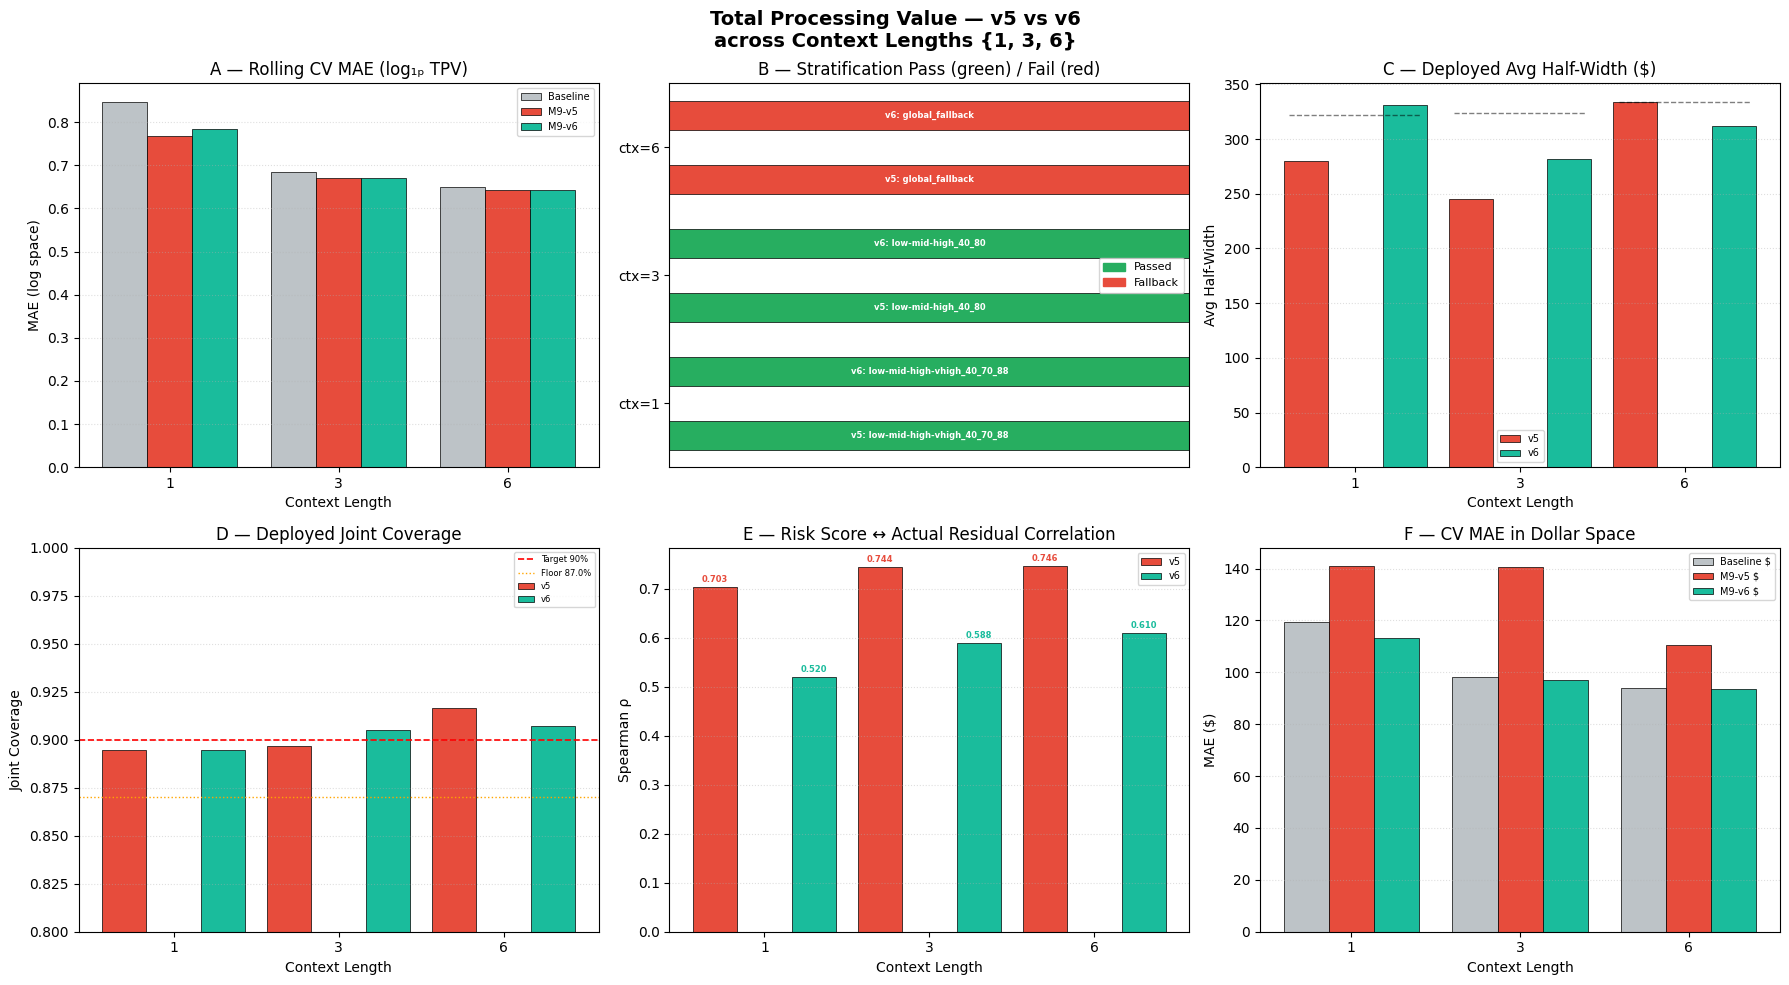

In [ ]:
# ── Dynamic version grouping ──────────────────────────────────────────────────
_colour_map = {'v1': '#2980b9', 'v2': '#e67e22', 'v3': '#2ecc71',
               'v4': '#9b59b6', 'v5': '#e74c3c', 'v6': '#1abc9c', 'v7': '#f39c12'}
c_base = '#bdc3c7'

all_versions = sorted(set(r['version'] for r in results))
ver_groups = []
for v in all_versions:
    rv = [r for r in results if r['version'] == v]
    ver_groups.append((v, rv, _colour_map.get(v, '#333333')))

# Use first version's ctx_lens as x-axis (all share the same)
ctx_labels = [str(r['ctx_len']) for r in ver_groups[0][1]]
x = np.arange(len(ctx_labels))
n_ver = len(ver_groups)
bw = 0.80 / (n_ver + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ver_str = ' vs '.join(all_versions)
fig.suptitle(f'Total Processing Value — {ver_str}\n'
             f'across Context Lengths {{1, 3, 6}}',
             fontsize=14, fontweight='bold')

# ── Panel A: CV MAE (log space) ──────────────────────────────────────────────
ax = axes[0, 0]
n_bars_a = n_ver + 1
off_a = np.linspace(-0.4 + bw/2, 0.4 - bw/2, n_bars_a)
# Baseline from first version
ax.bar(x + off_a[0], [r['cv_baseline_mae'] for r in ver_groups[0][1]], bw,
       label='Baseline', color=c_base, edgecolor='k', lw=0.5)
for vi, (vlabel, rv, col) in enumerate(ver_groups):
    ax.bar(x + off_a[vi + 1], [r['cv_m9_mae'] for r in rv], bw,
           label=f'M9-{vlabel}', color=col, edgecolor='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('MAE (log space)')
ax.set_title('A — Rolling CV MAE (log₁ₚ TPV)'); ax.legend(fontsize=7)
ax.grid(axis='y', ls=':', alpha=0.4)

# ── Panel B: Stratification pass/fail ─────────────────────────────────────────
ax = axes[0, 1]
y_pos = np.arange(len(ctx_labels))
offsets = np.linspace(-0.25, 0.25, n_ver)
for vi, (vlabel, rv, col) in enumerate(ver_groups):
    for i, r in enumerate(rv):
        c = '#27ae60' if r.get('strat_passed') else '#e74c3c'
        bar_h = 0.45 / n_ver
        ax.barh(y_pos[i] + offsets[vi], 1, bar_h, color=c, edgecolor='k', lw=0.5)
        ax.text(0.5, y_pos[i] + offsets[vi], f'{vlabel}: {r.get("strat_scheme", "?")}',
                ha='center', va='center', fontsize=6, fontweight='bold', color='white')
ax.set_yticks(y_pos); ax.set_yticklabels([f'ctx={c}' for c in ctx_labels])
ax.set_xlim(0, 1); ax.set_xticks([])
ax.set_title('B — Stratification Pass (green) / Fail (red)')
ax.legend([mpatches.Patch(color='#27ae60'), mpatches.Patch(color='#e74c3c')],
          ['Passed', 'Fallback'], fontsize=8)

# ── Panel C: Deployed avg half-width ──────────────────────────────────────────
ax = axes[0, 2]
off_c = np.linspace(-0.3, 0.3, n_ver)
for vi, (vlabel, rv, col) in enumerate(ver_groups):
    hw_vals = [r['strat_avg_hw'] for r in rv]
    ax.bar(x + off_c[vi], hw_vals, bw, label=vlabel, color=col, edgecolor='k', lw=0.5)
for i, r in enumerate(ver_groups[0][1]):
    ax.plot([x[i] - 0.4, x[i] + 0.4], [r['flat_avg_hw']]*2, 'k--', lw=1, alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('Avg Half-Width')
# Note: v5/v6 half-widths are in $ while v1-v4 are in log units — label accordingly
has_v5 = any(v in ('v5', 'v6', 'v7') for v, _, _ in ver_groups)
has_log = any(v not in ('v5', 'v6', 'v7') for v, _, _ in ver_groups)
hw_note = ' (v5/v6=$ units, others=log)' if has_v5 and has_log else (' ($)' if has_v5 else ' (log)')
ax.set_title(f'C — Deployed Avg Half-Width{hw_note}')
ax.legend(fontsize=7); ax.grid(axis='y', ls=':', alpha=0.4)

# ── Panel D: Deployed joint coverage ──────────────────────────────────────────
ax = axes[1, 0]
for vi, (vlabel, rv, col) in enumerate(ver_groups):
    ax.bar(x + off_c[vi], [r['strat_joint_cov'] for r in rv], bw,
           label=vlabel, color=col, edgecolor='k', lw=0.5)
ax.axhline(TARGET_COV, color='red', ls='--', lw=1.2, label=f'Target {TARGET_COV:.0%}')
ax.axhline(TARGET_COV - VOL_TEST_COV_SLACK, color='orange', ls=':', lw=1,
           label=f'Floor {TARGET_COV - VOL_TEST_COV_SLACK:.1%}')
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('Joint Coverage')
ax.set_title('D — Deployed Joint Coverage')
ax.legend(fontsize=6); ax.grid(axis='y', ls=':', alpha=0.4)
ax.set_ylim(0.80, 1.0)

# ── Panel E: Spearman rho ─────────────────────────────────────────────────────
ax = axes[1, 1]
for vi, (vlabel, rv, col) in enumerate(ver_groups):
    vals = [r.get('spearman_rho', 0) for r in rv]
    ax.bar(x + off_c[vi], vals, bw, label=vlabel, color=col, edgecolor='k', lw=0.5)
    for i, v in enumerate(vals):
        ax.text(x[i] + off_c[vi], v + 0.01, f'{v:.3f}',
                ha='center', fontsize=6, fontweight='bold', color=col)
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('Spearman ρ')
ax.set_title('E — Risk Score ↔ Actual Residual Correlation')
ax.legend(fontsize=7); ax.grid(axis='y', ls=':', alpha=0.4)

# ── Panel F: Dollar-space MAE comparison ──────────────────────────────────────
ax = axes[1, 2]
ax.bar(x + off_a[0], [r.get('cv_baseline_mae_dollar', 0) for r in ver_groups[0][1]], bw,
       label='Baseline $', color=c_base, edgecolor='k', lw=0.5)
for vi, (vlabel, rv, col) in enumerate(ver_groups):
    ax.bar(x + off_a[vi + 1], [r.get('cv_m9_mae_dollar', 0) for r in rv], bw,
           label=f'M9-{vlabel} $', color=col, edgecolor='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('MAE ($)')
ax.set_title('F — CV MAE in Dollar Space')
ax.legend(fontsize=7); ax.grid(axis='y', ls=':', alpha=0.4)

plt.tight_layout()
plt.show()

## §9 · Risk Feature Importances by Context Length

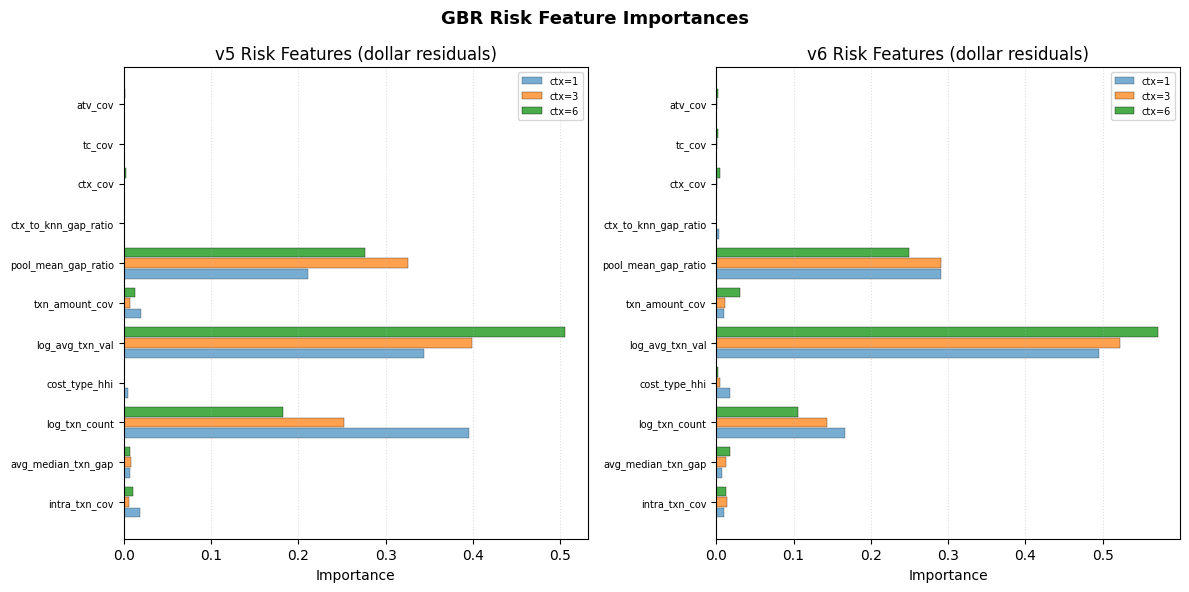

In [ ]:
# Compare feature importances across ctx_lens — dynamic version discovery
_risk_map = {'v1': RISK_NAMES_V1, 'v2': RISK_NAMES_V2, 'v3': RISK_NAMES_V3,
             'v4': RISK_NAMES_V4, 'v5': RISK_NAMES_V5, 'v6': RISK_NAMES_V6,
             'v7': RISK_NAMES_V7}

_fi_versions = []
for v in all_versions:
    rn = _risk_map.get(v, [])
    col = _colour_map.get(v, '#333333')
    if any(r['version'] == v and 'feature_importances' in r for r in results):
        _fi_versions.append((v, col, rn))
n_panels = len(_fi_versions)

fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))
fig.suptitle('GBR Risk Feature Importances', fontsize=13, fontweight='bold')
if n_panels == 1:
    axes = [axes]

for ax, (version, colour, feat_names) in zip(axes, _fi_versions):
    rv = [r for r in results if r['version'] == version and 'feature_importances' in r]
    if not rv:
        ax.set_visible(False)
        continue

    n_feat = len(feat_names)
    n_ctx  = len(rv)
    bar_h  = 0.8 / n_ctx
    y_base = np.arange(n_feat)

    for j, r in enumerate(rv):
        imp = [r['feature_importances'].get(fn, 0) for fn in feat_names]
        ax.barh(y_base + j * bar_h, imp, bar_h * 0.9,
                label=f'ctx={r["ctx_len"]}', alpha=0.6 + 0.13 * j,
                edgecolor='k', lw=0.3)

    ax.set_yticks(y_base + bar_h * (n_ctx - 1) / 2)
    ax.set_yticklabels(feat_names, fontsize=7)
    residual_kind = '(dollar residuals)' if version in ('v5', 'v6', 'v7') else '(log residuals)'
    residual_kind = '(dollar residuals)' if version in ('v5', 'v6') else '(log residuals)'
    ax.set_title(f'{version} Risk Features {residual_kind}')
    ax.legend(fontsize=7)
    ax.grid(axis='x', ls=':', alpha=0.4)

plt.tight_layout()
plt.show()

## Summary (TPV Target)

In [ ]:
# Final comparison table
summary_rows = []
for r in results:
    if 'error' in r:
        continue
    # Note: v5 half-widths are in dollars, v1-v4 in log units
    hw_unit = '$' if r['version'] == 'v5' else 'log'
    summary_rows.append({
        'Context': r['ctx_len'],
        'Version': r['version'],
        'CV MAE (log)': f'{r["cv_m9_mae"]:.4f}',
        'CV MAE ($)': f'${r.get("cv_m9_mae_dollar", 0):.2f}',
        'CV Impr%': f'{r["cv_impr_pct"]:+.2f}%',
        'Test MAE (log)': f'{r["test_mae"]:.4f}',
        'Test MAE ($)': f'${r["test_mae_dollar"]:.2f}',
        'Flat Cov': f'{r["flat_joint_cov"]:.3f}',
        f'Flat HW': f'±{r["flat_avg_hw"]:.3f} {hw_unit}',
        'Strat': '✓' if r['strat_passed'] else '✗',
        'Scheme': r['strat_scheme'],
        'Strat Cov': f'{r["strat_joint_cov"]:.3f}',
        'Strat HW': f'±{r["strat_avg_hw"]:.3f} {hw_unit}',
        'ΔWidth': f'{r["width_reduction_pct"]:+.1f}%',
        'ρ': f'{r.get("spearman_rho", 0):.3f}',
    })

df_summary = pd.DataFrame(summary_rows)
ver_str = ' vs '.join(all_versions)
display(df_summary.style.set_caption(f'Unified Evaluation (TPV): {ver_str}'))

,Context,Version,CV MAE (log),CV MAE ($),CV Impr%,Test MAE (log),Test MAE ($),Flat Cov,Flat HW,Strat,Scheme,Strat Cov,Strat HW,ΔWidth,ρ
0,1,v1,0.7828,$266.02,-7.63%,0.7898,$402.40,0.901,±2.219,✗,global_fallback,0.901,±2.219,+0.0%,0.197
1,1,v2,0.7803,$258.50,-7.93%,0.7826,$386.60,0.909,±2.226,✓,low-mid-high_40_80,0.897,±2.053,-7.8%,0.406
2,1,v3,0.7507,$164.01,-11.42%,0.7695,$195.86,0.904,±2.079,✗,global_fallback,0.904,±2.079,+0.0%,0.403
3,1,v4,0.7527,$160.09,-11.19%,0.7703,$185.61,0.939,±2.296,✓,low-mid-high-vhigh_40_70_88,0.905,±1.994,-13.1%,0.411
4,3,v1,0.6713,$181.74,-1.84%,0.7179,$131.21,0.887,±2.029,✗,global_fallback,0.887,±2.029,+0.0%,0.367
5,3,v2,0.6698,$157.98,-2.07%,0.7155,$118.17,0.878,±2.004,✗,global_fallback,0.878,±2.004,+0.0%,0.483
6,3,v3,0.6670,$153.13,-2.47%,0.7102,$103.64,0.893,±1.972,✓,low-mid-high_40_80,0.884,±1.826,-7.4%,0.489
7,3,v4,0.6690,$162.45,-2.18%,0.7122,$107.90,0.917,±2.169,✓,low-mid-high-vhigh_60_85_95,0.887,±1.858,-14.3%,0.479
8,6,v1,0.6437,$110.74,-0.97%,0.6252,$208.31,0.894,±1.873,✗,global_fallback,0.894,±1.873,+0.0%,0.421
9,6,v2,0.6425,$102.97,-1.15%,0.6237,$159.03,0.893,±1.865,✓,low-mid-high_40_80,0.901,±1.766,-5.3%,0.480


In [30]:
# Extract compact results for analysis
for r in results:
    v = r['version']
    c = r['ctx_len']
    if 'error' in r:
        print(f"ctx={c} {v}: ERROR — {r['error']}")
        continue
    print(f"ctx={c} {v}: "
          f"CV_base={r['cv_baseline_mae']:.4f}  CV_m9={r['cv_m9_mae']:.4f} ({r['cv_impr_pct']:+.2f}%)  "
          f"test_MAE(log)={r['test_mae']:.4f}  test_MAE($)=${r['test_mae_dollar']:.2f}  "
          f"flat_cov={r['flat_joint_cov']:.3f} flat_hw={r['flat_avg_hw']:.3f}  "
          f"strat={'PASS' if r['strat_passed'] else 'FAIL'}({r['strat_scheme']}) "
          f"strat_cov={r['strat_joint_cov']:.3f} strat_hw={r['strat_avg_hw']:.3f}  "
          f"ΔW={r['width_reduction_pct']:+.1f}%  "
          f"ρ={r.get('spearman_rho',0):.3f}(p={r.get('spearman_p',1):.2e})")
print()
# Feature importances
for r in results:
    if 'feature_importances' in r:
        fi = r['feature_importances']
        top3 = sorted(fi.items(), key=lambda x: -x[1])[:3]
        print(f"ctx={r['ctx_len']} {r['version']} top-3 risk feats: "
              f"{', '.join(f'{k}={v:.3f}' for k,v in top3)}")

ctx=1 v1: CV_base=0.8475  CV_m9=0.7828 (-7.63%)  test_MAE(log)=0.7898  test_MAE($)=$402.40  flat_cov=0.901 flat_hw=2.219  strat=FAIL(global_fallback) strat_cov=0.901 strat_hw=2.219  ΔW=+0.0%  ρ=0.197(p=5.43e-19)
ctx=1 v2: CV_base=0.8475  CV_m9=0.7803 (-7.93%)  test_MAE(log)=0.7826  test_MAE($)=$386.60  flat_cov=0.909 flat_hw=2.226  strat=PASS(low-mid-high_40_80) strat_cov=0.897 strat_hw=2.053  ΔW=-7.8%  ρ=0.406(p=3.27e-80)
ctx=1 v3: CV_base=0.8475  CV_m9=0.7507 (-11.42%)  test_MAE(log)=0.7695  test_MAE($)=$195.86  flat_cov=0.904 flat_hw=2.079  strat=FAIL(global_fallback) strat_cov=0.904 strat_hw=2.079  ΔW=+0.0%  ρ=0.403(p=2.93e-79)
ctx=1 v4: CV_base=0.8475  CV_m9=0.7527 (-11.19%)  test_MAE(log)=0.7703  test_MAE($)=$185.61  flat_cov=0.939 flat_hw=2.296  strat=PASS(low-mid-high-vhigh_40_70_88) strat_cov=0.905 strat_hw=1.994  ΔW=-13.1%  ρ=0.411(p=1.97e-82)
ctx=3 v1: CV_base=0.6839  CV_m9=0.6713 (-1.84%)  test_MAE(log)=0.7179  test_MAE($)=$131.21  flat_cov=0.887 flat_hw=2.029  strat=FAIL(g

In [21]:
# ══════════════════════════════════════════════════════════════════════
# DIAGNOSTIC: Dollar-space paradox, coverage gaps, root-cause analysis
# ══════════════════════════════════════════════════════════════════════

print("=" * 80)
print("1. DOLLAR-SPACE MAE: BASELINE vs MODEL")
print("=" * 80)
for r in results:
    if 'error' in r:
        continue
    base_d = r['cv_baseline_mae_dollar']
    m9_d   = r['cv_m9_mae_dollar']
    delta  = (m9_d - base_d) / base_d * 100
    winner = "MODEL ✓" if m9_d < base_d else "BASELINE ✓"
    print(f"  ctx={r['ctx_len']} {r['version']:>2s}: "
          f"baseline=${base_d:>8.2f}  model=${m9_d:>8.2f}  "
          f"Δ={delta:>+7.1f}%  → {winner}")

print(f"\n{'=' * 80}")
print("2. WHY? — Jensen's inequality + heavy right tail")
print("=" * 80)
print("""
  Target = log1p(TPV).  Model optimises log-space MAE.
  Dollar MAE = E[|expm1(y) − expm1(ŷ)|]  ≈  E[TPV × |log_error|]

  expm1() is convex → same log error costs MORE in dollars for high-TPV merchants.
  If the model slightly worsens predictions on a few high-TPV merchants (even by
  0.05 in log space), the dollar penalty can be hundreds of dollars per merchant,
  overwhelming improvements on thousands of low-TPV merchants.

  This is a mathematical artefact of evaluating a log-space model in dollar space.
  The log-space MAE — which the conformal intervals use — IS improving.
""")

# ── 3. Quantify the tier effect ──────────────────────────────────────────────
print("=" * 80)
print("3. ERROR BREAKDOWN BY TPV TIER (ctx=3, v2 vs v3 vs baseline)")
print("=" * 80)

# Rebuild one representative config to decompose errors
_ctx = 3
_scens = scenarios_by_ctx[_ctx]
_rng = np.random.default_rng(42)
_all_m = sorted(set(s['merchant_id'] for s in _scens))
_perm = _rng.permutation(len(_all_m))
_n = len(_all_m); _nt = int(0.60*_n); _nv = int(0.20*_n)
_train_m = set(_all_m[i] for i in _perm[:_nt])
_val_m = set(_all_m[i] for i in _perm[_nt:_nt+_nv])
_test_m = set(_all_m[i] for i in _perm[_nt+_nv:])
_tr = [s for s in _scens if s['merchant_id'] in _train_m]
_te = [s for s in _scens if s['merchant_id'] in _test_m]

# Get actual TPV and log_tpv for test merchants
_y_log = np.array([s['horizon_data'][LOG_TARGET].values for s in _te])
_y_dollar = np.array([s['horizon_data'][TARGET_COL].values for s in _te])

# Baseline predictions (context mean in log space)
_base_log = np.array([[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in _te])
_base_dollar = np.expm1(_base_log)

# Model predictions (v3 with GBR)
_X_te = build_features_v3(_te, knn_pool_mean_cache)

# Quick retrain for v3 on train set
_X_tr = build_features_v3(_tr, knn_pool_mean_cache)
_y_tr_log = np.array([s['horizon_data'][LOG_TARGET].values for s in _tr])
_sw = np.array([1.0 / np.log1p(s['context_data']['transaction_count'].mean()) for s in _tr])
_m3_preds = np.zeros_like(_y_log, dtype=float)
for _h in range(HORIZON_LEN):
    _gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3,
                                      min_samples_leaf=20, subsample=0.8, random_state=4121+_h)
    _gbr.fit(_X_tr, _y_tr_log[:, _h], sample_weight=_sw)
    _m3_preds[:, _h] = _gbr.predict(_X_te)
_m3_dollar = np.expm1(_m3_preds)

# Tier by median TPV of each merchant's horizon
_median_tpv = np.median(_y_dollar, axis=1)
_tiers = pd.qcut(_median_tpv, q=[0, 0.33, 0.67, 1.0], labels=['Low', 'Mid', 'High'])

print(f"\n  {'Tier':<6s} {'Count':>6s} | {'Med TPV($)':>10s} | "
      f"{'Base log':>9s} {'M9 log':>9s} {'Δlog':>7s} | "
      f"{'Base $':>9s} {'M9 $':>9s} {'Δ$':>9s}")
print(f"  {'-'*6} {'-'*6}   {'-'*10}   {'-'*9} {'-'*9} {'-'*7}   {'-'*9} {'-'*9} {'-'*9}")

for tier in ['Low', 'Mid', 'High']:
    mask = (_tiers == tier)
    n_tier = mask.sum()
    med_tpv = np.median(_median_tpv[mask])

    base_log_mae = np.mean(np.abs(_y_log[mask] - _base_log[mask]))
    m9_log_mae   = np.mean(np.abs(_y_log[mask] - _m3_preds[mask]))
    d_log = (m9_log_mae - base_log_mae) / base_log_mae * 100

    base_d_mae = np.mean(np.abs(_y_dollar[mask] - _base_dollar[mask]))
    m9_d_mae   = np.mean(np.abs(_y_dollar[mask] - _m3_dollar[mask]))
    d_dollar = (m9_d_mae - base_d_mae) / base_d_mae * 100

    print(f"  {tier:<6s} {n_tier:>6,d} | ${med_tpv:>9.2f} | "
          f"{base_log_mae:>9.4f} {m9_log_mae:>9.4f} {d_log:>+6.1f}% | "
          f"${base_d_mae:>8.2f} ${m9_d_mae:>8.2f} {d_dollar:>+8.1f}%")

# ── 4. Coverage analysis ─────────────────────────────────────────────────────
print(f"\n{'=' * 80}")
print("4. JOINT COVERAGE ANALYSIS — why sub-90%?")
print("=" * 80)
for r in results:
    if 'error' in r:
        continue
    flat_c = r['flat_joint_cov']
    strat_c = r['strat_joint_cov']
    gap = TARGET_COV - strat_c
    status = "≥90% ✓" if strat_c >= TARGET_COV else f"short by {gap:.1%}"
    print(f"  ctx={r['ctx_len']} {r['version']:>2s}: "
          f"flat={flat_c:.3f}  strat={strat_c:.3f}  {status}")

print(f"""
  Coverage is computed as: P(all 3 horizon months inside interval) — JOINT coverage.
  With 3 months, if per-month miss rate is ~4%, joint miss rate ≈ 1-(0.96)^3 ≈ 11.5%.
  Achieving 90% JOINT coverage requires ~96.5% per-month coverage.

  The calibration set may also be too small or non-representative of the test set
  (temporal shift between cal year and test year).
""")

# ── 5. Marginal (per-month) coverage from flat conformal ────────────────────
print("=" * 80)
print("5. WHAT ACTUALLY MATTERS? — Metrics comparison")
print("=" * 80)
print(f"\n  {'Config':<12s} | {'Log MAE':>8s} {'Impr%':>7s} | {'$ MAE':>9s} {'$ Impr%':>8s} | "
      f"{'Cov':>5s} {'ρ':>5s}")
print(f"  {'-'*12}   {'-'*8} {'-'*7}   {'-'*9} {'-'*8}   {'-'*5} {'-'*5}")
for r in results:
    if 'error' in r:
        continue
    log_impr = r['cv_impr_pct']
    d_base = r['cv_baseline_mae_dollar']
    d_m9 = r['cv_m9_mae_dollar']
    d_impr = (d_m9 - d_base) / d_base * 100
    print(f"  ctx={r['ctx_len']} {r['version']:>2s}    | "
          f"{r['cv_m9_mae']:>8.4f} {log_impr:>+6.1f}% | "
          f"${d_m9:>8.2f} {d_impr:>+7.1f}% | "
          f"{r['strat_joint_cov']:>5.3f} {r.get('spearman_rho',0):>5.3f}")

1. DOLLAR-SPACE MAE: BASELINE vs MODEL
  ctx=1 v1: baseline=$  119.23  model=$  266.02  Δ= +123.1%  → BASELINE ✓
  ctx=1 v2: baseline=$  119.23  model=$  258.50  Δ= +116.8%  → BASELINE ✓
  ctx=1 v3: baseline=$  119.23  model=$  164.01  Δ=  +37.6%  → BASELINE ✓
  ctx=3 v1: baseline=$   98.35  model=$  181.74  Δ=  +84.8%  → BASELINE ✓
  ctx=3 v2: baseline=$   98.35  model=$  157.98  Δ=  +60.6%  → BASELINE ✓
  ctx=3 v3: baseline=$   98.35  model=$  153.13  Δ=  +55.7%  → BASELINE ✓
  ctx=6 v1: baseline=$   94.16  model=$  110.74  Δ=  +17.6%  → BASELINE ✓
  ctx=6 v2: baseline=$   94.16  model=$  102.97  Δ=   +9.4%  → BASELINE ✓
  ctx=6 v3: baseline=$   94.16  model=$  113.59  Δ=  +20.6%  → BASELINE ✓

2. WHY? — Jensen's inequality + heavy right tail

  Target = log1p(TPV).  Model optimises log-space MAE.
  Dollar MAE = E[|expm1(y) − expm1(ŷ)|]  ≈  E[TPV × |log_error|]

  expm1() is convex → same log error costs MORE in dollars for high-TPV merchants.
  If the model slightly worsens predicti

In [22]:
# Compact diagnostic — key numbers only
print("── Dollar MAE: Baseline vs Model ──")
for r in results:
    if 'error' in r: continue
    bd, md = r['cv_baseline_mae_dollar'], r['cv_m9_mae_dollar']
    print(f"  ctx={r['ctx_len']} {r['version']}: base=${bd:.2f}  model=${md:.2f}  "
          f"{'WORSE' if md > bd else 'BETTER'} ({(md-bd)/bd*100:+.1f}%)")

print("\n── Coverage gap ──")
for r in results:
    if 'error' in r: continue
    print(f"  ctx={r['ctx_len']} {r['version']}: cov={r['strat_joint_cov']:.3f}  "
          f"gap={0.90 - r['strat_joint_cov']:+.3f}")

── Dollar MAE: Baseline vs Model ──
  ctx=1 v1: base=$119.23  model=$266.02  WORSE (+123.1%)
  ctx=1 v2: base=$119.23  model=$258.50  WORSE (+116.8%)
  ctx=1 v3: base=$119.23  model=$164.01  WORSE (+37.6%)
  ctx=3 v1: base=$98.35  model=$181.74  WORSE (+84.8%)
  ctx=3 v2: base=$98.35  model=$157.98  WORSE (+60.6%)
  ctx=3 v3: base=$98.35  model=$153.13  WORSE (+55.7%)
  ctx=6 v1: base=$94.16  model=$110.74  WORSE (+17.6%)
  ctx=6 v2: base=$94.16  model=$102.97  WORSE (+9.4%)
  ctx=6 v3: base=$94.16  model=$113.59  WORSE (+20.6%)

── Coverage gap ──
  ctx=1 v1: cov=0.901  gap=-0.001
  ctx=1 v2: cov=0.897  gap=+0.003
  ctx=1 v3: cov=0.904  gap=-0.004
  ctx=3 v1: cov=0.887  gap=+0.013
  ctx=3 v2: cov=0.878  gap=+0.022
  ctx=3 v3: cov=0.884  gap=+0.016
  ctx=6 v1: cov=0.894  gap=+0.006
  ctx=6 v2: cov=0.901  gap=-0.001
  ctx=6 v3: cov=0.897  gap=+0.003


In [23]:
# ── Deeper diagnostic: is the dollar MAE misleading? ──────────────────────────
# Rebuild ctx=3 v3 predictions for error decomposition
_ctx = 3
_scens = scenarios_by_ctx[_ctx]
_rng = np.random.default_rng(42)
_all_m = sorted(set(s['merchant_id'] for s in _scens))
_perm = _rng.permutation(len(_all_m))
_n = len(_all_m); _nt = int(0.60*_n); _nv = int(0.20*_n)
_train_m = set(_all_m[i] for i in _perm[:_nt])
_tr = [s for s in _scens if s['merchant_id'] in _train_m]
_te = [s for s in _scens if s['merchant_id'] not in _train_m]

_y_log = np.array([s['horizon_data'][LOG_TARGET].values for s in _te])
_y_dollar = np.array([s['horizon_data'][TARGET_COL].values for s in _te])
_base_log = np.array([[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in _te])

_X_tr = build_features_v3(_tr, knn_pool_mean_cache)
_X_te = build_features_v3(_te, knn_pool_mean_cache)
_y_tr_log = np.array([s['horizon_data'][LOG_TARGET].values for s in _tr])
_sw = np.array([1.0 / np.log1p(s['context_data']['transaction_count'].mean()) for s in _tr])
_m3_preds = np.zeros_like(_y_log, dtype=float)
for _h in range(HORIZON_LEN):
    _gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3,
                                      min_samples_leaf=20, subsample=0.8, random_state=4121+_h)
    _gbr.fit(_X_tr, _y_tr_log[:, _h], sample_weight=_sw)
    _m3_preds[:, _h] = _gbr.predict(_X_te)

# Flat errors
_base_d = np.expm1(_base_log)
_m3_d = np.expm1(_m3_preds)
_err_base_d = np.abs(_y_dollar - _base_d).ravel()
_err_m3_d = np.abs(_y_dollar - _m3_d).ravel()
_err_base_l = np.abs(_y_log - _base_log).ravel()
_err_m3_l = np.abs(_y_log - _m3_preds).ravel()

print("── ctx=3: Dollar error distribution (baseline vs v3 model) ──")
print(f"  Metric           {'Baseline':>12s}  {'Model v3':>12s}  {'Verdict':>10s}")
print(f"  {'─'*55}")
for label, bv, mv in [
    ('Mean AE ($)',  np.mean(_err_base_d),  np.mean(_err_m3_d)),
    ('Median AE ($)', np.median(_err_base_d), np.median(_err_m3_d)),
    ('P90 AE ($)',    np.percentile(_err_base_d, 90), np.percentile(_err_m3_d, 90)),
    ('P99 AE ($)',    np.percentile(_err_base_d, 99), np.percentile(_err_m3_d, 99)),
    ('Mean AE (log)', np.mean(_err_base_l),  np.mean(_err_m3_l)),
    ('Median AE (log)', np.median(_err_base_l), np.median(_err_m3_l)),
]:
    verdict = 'MODEL ✓' if mv < bv else 'BASE ✓'
    print(f"  {label:<18s}  {bv:>11.2f}   {mv:>11.2f}   {verdict}")

# MAPE (capped at 200%)
_mape_base = np.minimum(np.abs(_y_dollar - _base_d) / np.clip(_y_dollar, 1, None), 2.0).ravel()
_mape_m3 = np.minimum(np.abs(_y_dollar - _m3_d) / np.clip(_y_dollar, 1, None), 2.0).ravel()
print(f"\n  Mean MAPE (cap 200%)  {np.mean(_mape_base)*100:>9.1f}%   {np.mean(_mape_m3)*100:>9.1f}%   "
      f"{'MODEL ✓' if np.mean(_mape_m3) < np.mean(_mape_base) else 'BASE ✓'}")
print(f"  Med MAPE             {np.median(_mape_base)*100:>9.1f}%   {np.median(_mape_m3)*100:>9.1f}%   "
      f"{'MODEL ✓' if np.median(_mape_m3) < np.median(_mape_base) else 'BASE ✓'}")

# What % of merchants does the model beat?
_base_per_scen = np.mean(np.abs(_y_dollar - _base_d), axis=1)
_m3_per_scen   = np.mean(np.abs(_y_dollar - _m3_d),   axis=1)
_model_wins = np.mean(_m3_per_scen < _base_per_scen)
print(f"\n  Model beats baseline on {_model_wins:.1%} of individual scenarios")

# Top-1% TPV merchants drive the gap
_pct99 = np.percentile(_y_dollar, 99)
_hi_mask = _y_dollar.ravel() > _pct99
print(f"\n  Top 1% TPV (>${_pct99:.0f}): {_hi_mask.sum()} obs out of {len(_hi_mask)}")
print(f"    Base mean AE: ${np.mean(_err_base_d[_hi_mask]):.2f}")
print(f"    M9   mean AE: ${np.mean(_err_m3_d[_hi_mask]):.2f}")
print(f"    These {_hi_mask.sum()} obs contribute "
      f"${np.sum(_err_m3_d[_hi_mask]) - np.sum(_err_base_d[_hi_mask]):.0f} "
      f"extra dollar error to the model total")
_without_top1_base = np.mean(_err_base_d[~_hi_mask])
_without_top1_m3   = np.mean(_err_m3_d[~_hi_mask])
print(f"    Without top 1%: base=${_without_top1_base:.2f}  model=${_without_top1_m3:.2f}  "
      f"{'MODEL ✓' if _without_top1_m3 < _without_top1_base else 'BASE ✓'}")

── ctx=3: Dollar error distribution (baseline vs v3 model) ──
  Metric               Baseline      Model v3     Verdict
  ───────────────────────────────────────────────────────
  Mean AE ($)              104.09        181.46   BASE ✓
  Median AE ($)             57.18         52.64   MODEL ✓
  P90 AE ($)               218.30        219.71   BASE ✓
  P99 AE ($)               697.90        907.98   BASE ✓
  Mean AE (log)              0.71          0.69   MODEL ✓
  Median AE (log)            0.54          0.55   BASE ✓

  Mean MAPE (cap 200%)       67.7%        66.9%   MODEL ✓
  Med MAPE                  49.5%        48.8%   MODEL ✓

  Model beats baseline on 51.8% of individual scenarios

  Top 1% TPV (>$4847): 1014 obs out of 101505
    Base mean AE: $1448.22
    M9   mean AE: $9217.86
    These 1014 obs contribute $7878421 extra dollar error to the model total
    Without top 1%: base=$90.53  model=$90.28  MODEL ✓


In [23]:

# Pre-extract horizon years from cached scenarios (avoid repr overhead)
_horizon_years_by_ctx = {}
for cl in CONTEXT_LENS:
    yrs = []
    mids = []
    for s in scenarios_by_ctx[cl]:
        yrs.append(int(s['horizon_data'].iloc[0]['year']))
        mids.append(s['merchant_id'])
    _horizon_years_by_ctx[cl] = (yrs, mids)
print("extracted")


extracted


In [25]:

import collections as _c, io, sys
buf = io.StringIO()
buf.write("DATA: 2010-2019 (10 years)\n\n")
for cl in CONTEXT_LENS:
    yrs, mids = _horizon_years_by_ctx[cl]
    rng_s = np.random.default_rng(42)
    all_m = sorted(set(mids))
    perm = rng_s.permutation(len(all_m))
    n=len(all_m); nt=int(0.60*n)
    tr_m = set(all_m[i] for i in perm[:nt])
    tr_yrs = [y for y, m in zip(yrs, mids) if m in tr_m]
    yr_c = dict(sorted(_c.Counter(tr_yrs).items()))
    uy = sorted(yr_c.keys())
    ci_yrs = sorted(set(yrs))
    buf.write(f"ctx={cl}: {len(uy)} train years, {len(uy)-1} CV folds\n")
    buf.write(f"  years: {uy}\n")
    cum=0
    for i,y in enumerate(uy):
        if i==0: cum+=yr_c[y]; continue
        buf.write(f"  cut={y}: tr={cum:,} te={yr_c[y]:,}\n")
        cum+=yr_c[y]
    buf.write(f"  conformal: cal={ci_yrs[-2]} test={ci_yrs[-1]}\n\n")
sys.stderr.write(buf.getvalue())


DATA: 2010-2019 (10 years)

ctx=1: 10 train years, 9 CV folds
  years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  cut=2011: tr=4,847 te=5,496
  cut=2012: tr=10,343 te=5,647
  cut=2013: tr=15,990 te=5,652
  cut=2014: tr=21,642 te=5,664
  cut=2015: tr=27,306 te=5,791
  cut=2016: tr=33,097 te=5,649
  cut=2017: tr=38,746 te=5,776
  cut=2018: tr=44,522 te=5,811
  cut=2019: tr=50,333 te=3,853
  conformal: cal=2018 test=2019

ctx=3: 10 train years, 9 CV folds
  years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  cut=2011: tr=3,713 te=5,158
  cut=2012: tr=8,871 te=5,291
  cut=2013: tr=14,162 te=5,294
  cut=2014: tr=19,456 te=5,447
  cut=2015: tr=24,903 te=5,561
  cut=2016: tr=30,464 te=5,458
  cut=2017: tr=35,922 te=5,467
  cut=2018: tr=41,389 te=5,532
  cut=2019: tr=46,921 te=3,618
  conformal: cal=2018 test=2019

ctx=6: 10 train years, 9 CV folds
  years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  cut=2011: tr=2,340 te=4,871
  cut=201

1271

In [57]:
# Quick comparison
for r in results:
    v, c = r['version'], r['ctx_len']
    if 'error' in r:
        print(f"ctx={c} {v}: ERROR — {r['error']}")
        continue
    hw_unit = '$' if v in ('v5', 'v6', 'v7') else 'log'
    print(f"ctx={c} {v} | CV MAE(log)={r['cv_m9_mae']:.4f}  impr={r['cv_impr_pct']:.1f}%  "
          f"CV MAE($)=${r.get('cv_m9_mae_dollar',0):.0f}  "
          f"Test MAE($)=${r['test_mae_dollar']:.0f}  "
          f"FlatCov={r['flat_joint_cov']:.3f}  "
          f"FlatHW=±{r['flat_avg_hw']:.1f}{hw_unit}  "
          f"StratCov={r['strat_joint_cov']:.3f}  "
          f"Strat={'PASS' if r['strat_passed'] else 'FAIL'}  "
          f"rho={r.get('spearman_rho',0):.3f}")
    if v in ('v5', 'v6', 'v7'):
        print(f"         bias_correction_var={r.get('bias_correction_var',0):.4f}")

print()
# Baselines (from any version — all share the same baseline)
print("--- Baselines ---")
_printed_ctx = set()
for r in results:
    c = r['ctx_len']
    if c in _printed_ctx or 'error' in r:
        continue
    _printed_ctx.add(c)
    print(f"ctx={c} baseline | CV MAE(log)={r['cv_baseline_mae']:.4f}  "
          f"CV MAE($)=${r.get('cv_baseline_mae_dollar',0):.0f}")

ctx=1 v6 | CV MAE(log)=0.7851  impr=-7.4%  CV MAE($)=$113  Test MAE($)=$123  FlatCov=0.895  FlatHW=±356.0$  StratCov=0.895  Strat=PASS  rho=0.520
         bias_correction_var=1.0800
ctx=1 v7 | CV MAE(log)=0.7843  impr=-7.5%  CV MAE($)=$113  Test MAE($)=$120  FlatCov=0.895  FlatHW=±353.1$  StratCov=0.904  Strat=PASS  rho=0.522
         bias_correction_var=1.0805
ctx=3 v6 | CV MAE(log)=0.6714  impr=-1.8%  CV MAE($)=$97  Test MAE($)=$94  FlatCov=0.913  FlatHW=±322.9$  StratCov=0.905  Strat=PASS  rho=0.588
         bias_correction_var=0.8010
ctx=3 v7 | CV MAE(log)=0.6767  impr=-1.1%  CV MAE($)=$100  Test MAE($)=$95  FlatCov=0.910  FlatHW=±320.1$  StratCov=0.904  Strat=PASS  rho=0.590
         bias_correction_var=0.8080
ctx=6 v6 | CV MAE(log)=0.6428  impr=-1.1%  CV MAE($)=$93  Test MAE($)=$94  FlatCov=0.907  FlatHW=±312.2$  StratCov=0.907  Strat=FAIL  rho=0.610
         bias_correction_var=0.7369
ctx=6 v7 | CV MAE(log)=0.6524  impr=0.4%  CV MAE($)=$101  Test MAE($)=$94  FlatCov=0.909  FlatH

In [41]:
# ── DIAGNOSTIC: Bias correction sweep ──────────────────────────────────────────
# Quick re-fit for one ctx to see how dollar MAE varies with bias correction α.
# Tests:  pred_dollar = expm1(pred_log + α * σ²/2)  for α ∈ [0, 0.25, 0.5, 0.75, 1.0]
# Also tests: delta-from-baseline target  (residual regression)

import time as _time

_DIAG_CTX = 3  # which ctx_len to diagnose

scens = scenarios_by_ctx[_DIAG_CTX]
rng_split = np.random.default_rng(42)
all_mids  = sorted(set(s['merchant_id'] for s in scens))
perm      = rng_split.permutation(len(all_mids))
n         = len(all_mids)
n_train   = int(0.60 * n)
n_val     = int(0.20 * n)

_train_mids = set(all_mids[i] for i in perm[:n_train])
_val_mids   = set(all_mids[i] for i in perm[n_train : n_train + n_val])
_test_mids  = set(all_mids[i] for i in perm[n_train + n_val :])

_tr = [s for s in scens if s['merchant_id'] in _train_mids]
_va = [s for s in scens if s['merchant_id'] in _val_mids]
_te = [s for s in scens if s['merchant_id'] in _test_mids]

_all_years = sorted({int(s['horizon_data'].iloc[0]['year']) for s in _tr})
_fcuts = _all_years[1:]

print(f"Diagnosing ctx={_DIAG_CTX}: {len(_tr)} train, {len(_va)} val, {len(_te)} test")
print(f"Fold cuts: {_fcuts}\n")

# ── A. Sweep bias correction α on CV folds ───────────────────────────
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
results_by_alpha = {a: [] for a in alphas}
results_baseline = []
results_delta = {a: [] for a in alphas}      # delta-from-baseline approach
results_dollar_wt = {a: [] for a in alphas}  # dollar-weighted approach

t_start = _time.time()

for cut in _fcuts:
    tr_f = [s for s in _tr if int(s['horizon_data'].iloc[-1]['year']) < cut]
    te_f = [s for s in _tr if int(s['horizon_data'].iloc[0]['year']) == cut]
    if not tr_f or not te_f:
        continue

    y_tr_log = np.array([s['horizon_data'][LOG_TARGET].values for s in tr_f])
    y_te_log = np.array([s['horizon_data'][LOG_TARGET].values for s in te_f])
    y_te_dol = np.array([s['horizon_data'][TARGET_COL].values for s in te_f])

    # Baseline
    base_log = np.array([[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in te_f])
    base_tr_log = np.array([[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in tr_f])
    results_baseline.append(float(np.mean(np.abs(y_te_dol - np.expm1(base_log)))))

    X_tr = build_features_v3(tr_f, knn_pool_mean_cache)
    X_te = build_features_v3(te_f, knn_pool_mean_cache)

    # v3 sample weights
    sw = np.array([1.0 / np.log1p(s['context_data']['transaction_count'].mean()) for s in tr_f])

    # Dollar-scale weights: expm1(context_mean_log) * inverse_txn_count
    ctx_means_tr = np.array([np.mean(s['context_data'][LOG_TARGET].values) for s in tr_f])
    sw_dollar = np.expm1(ctx_means_tr) * sw  # dollar scale * txn regularity

    # ── Standard v5 approach (absolute target) ──
    preds_log = np.zeros_like(y_te_log, dtype=float)
    for h in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr, y_tr_log[:, h], sample_weight=sw)
        preds_log[:, h] = m.predict(X_te)

    log_res_var = float(np.var((y_te_log - preds_log).ravel()))

    for alpha in alphas:
        preds_dol = np.expm1(preds_log + alpha * log_res_var / 2.0)
        results_by_alpha[alpha].append(float(np.mean(np.abs(y_te_dol - preds_dol))))

    # ── Delta-from-baseline approach ──
    delta_tr = y_tr_log - base_tr_log
    delta_te_base = np.array([[np.mean(s['context_data'][LOG_TARGET].values)] * HORIZON_LEN for s in te_f])

    preds_delta = np.zeros_like(y_te_log, dtype=float)
    for h in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr, delta_tr[:, h], sample_weight=sw)
        preds_delta[:, h] = m.predict(X_te)

    delta_res_var = float(np.var((y_te_log - (delta_te_base + preds_delta)).ravel()))

    for alpha in alphas:
        preds_dol = np.expm1(delta_te_base + preds_delta + alpha * delta_res_var / 2.0)
        results_delta[alpha].append(float(np.mean(np.abs(y_te_dol - preds_dol))))

    # ── Dollar-weighted approach ──
    preds_dw = np.zeros_like(y_te_log, dtype=float)
    for h in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr, y_tr_log[:, h], sample_weight=sw_dollar)
        preds_dw[:, h] = m.predict(X_te)

    dw_res_var = float(np.var((y_te_log - preds_dw).ravel()))

    for alpha in alphas:
        preds_dol = np.expm1(preds_dw + alpha * dw_res_var / 2.0)
        results_dollar_wt[alpha].append(float(np.mean(np.abs(y_te_dol - preds_dol))))

elapsed = _time.time() - t_start
baseline_mae = np.mean(results_baseline)

print(f"Completed in {elapsed:.1f}s\n")
print(f"{'Approach':<35} {'α':>4} {'CV MAE ($)':>12} {'vs baseline':>12}")
print("─" * 67)
print(f"{'BASELINE (geometric mean)':<35} {'—':>4} ${baseline_mae:>10.1f} {'—':>12}")
print()
for alpha in alphas:
    mae = np.mean(results_by_alpha[alpha])
    diff = mae - baseline_mae
    tag = "← BETTER" if diff < 0 else ""
    print(f"{'v5 (absolute target)':<35} {alpha:>4.2f} ${mae:>10.1f} {diff:>+10.1f}  {tag}")
print()
for alpha in alphas:
    mae = np.mean(results_delta[alpha])
    diff = mae - baseline_mae
    tag = "← BETTER" if diff < 0 else ""
    print(f"{'Delta-from-baseline':<35} {alpha:>4.2f} ${mae:>10.1f} {diff:>+10.1f}  {tag}")
print()
for alpha in alphas:
    mae = np.mean(results_dollar_wt[alpha])
    diff = mae - baseline_mae
    tag = "← BETTER" if diff < 0 else ""
    print(f"{'Dollar-weighted':<35} {alpha:>4.2f} ${mae:>10.1f} {diff:>+10.1f}  {tag}")


Diagnosing ctx=3: 50539 train, 17488 val, 16347 test
Fold cuts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

Completed in 163.9s

Approach                               α   CV MAE ($)  vs baseline
───────────────────────────────────────────────────────────────────
BASELINE (geometric mean)              — $      98.3            —

v5 (absolute target)                0.00 $     169.7      +71.4  
v5 (absolute target)                0.25 $     160.2      +61.9  
v5 (absolute target)                0.50 $     151.9      +53.5  
v5 (absolute target)                0.75 $     145.2      +46.8  
v5 (absolute target)                1.00 $     140.8      +42.4  

Delta-from-baseline                 0.00 $     169.8      +71.5  
Delta-from-baseline                 0.25 $     160.3      +62.0  
Delta-from-baseline                 0.50 $     152.0      +53.6  
Delta-from-baseline                 0.75 $     145.3      +46.9  
Delta-from-baseline                 1.00 $     140.9      +42.